#**Prediksi Keputusan Nasabah dalam Berlangganan Deposito Berjangka Menggunakan Model Machine Learning (ML)**
---
(Data Science Project)

---

##**Abstrak**

---
Notebook ini menyajikan hasil analisis data terhadap dataset kampanye promosi deposito berjangka suatu bank. Dataset mencakup informasi demografis nasabah, riwayat keuangan, serta detail interaksi telepon dari kampanye untuk produk deposito berjangka. Tujuan utama dari analisis ini adalah untuk membangun model klasifikasi yang mampu memprediksi apakah seorang nasabah akan berlangganan deposito berjangka (y = yes/no), mengidentifikasi faktor yang memberikan pengaruh besar bagi keputusan nasabah, dan memberikan rekomendasi untuk meningkatkan efisiensi departemen pemasaran bank. Proses yang diterapkan meliputi Exploratory Data Analysis (EDA), data preprocessing (encoding, scaling), dan data modelling. Melalui EDA, didapatkan beberapa insight, seperti dataset yang digunakan rupanya tidak seimbang (imbalance) dan karakteristik nasabah yang memiliki tingkat konversi tertinggi. Setelah itu, data dibersihkan agar siap untuk dimodelkan dengan algoritma Decision Tree, Random Forest, dan Extreme Gradient Boosting (XGBoost). Evaluasi dilakukan menggunakan metrik akurasi, precision, recall, F1-score, ROC-AUC, dan PR-AUC. Hasil menunjukkan bahwa XGBoost memberikan performa paling baik secara keseluruhan dengan akurasi 93%, nilai ROC-AUC mencapai 0,97, dan nilai PR-AUC mencapai 0,846 yang mengindikasikan kemampuan model yang sangat baik dalam mengklasifikasi, meski data yang digunakan tidak seimbang. Interpretasi yang diperoleh adalah durasi panggilan, saldo, dan hasil kampanye sebelumnya merupakan faktor yang mempengaruhi keputusan nasabah untuk berlangganan deposito berjangka.

---

##**Pernyataan Masalah dan Tujuan**
---
###Pernyataan Masalah
---
Suatu bank mengadakan kampanye promosi deposito berjangka kepada para nasabahnya, namun hasil yang didapatkan kurang memuaskan.

Kegiatan promosi ini membutuhkan sumber daya (waktu  dan biaya) yang cukup besar, karena melibatkan beberapa staff untuk mengadakan kontak dengan nasabah. Namun, jumlah nasabah yang berlangganan deposito berjangka tidak bertambah signifikan. Hal ini disebabkan oleh kurangnya pengetahuan mengenai karakteristik nasabah, sehingga para staff sulit memetakan target nasabah yang perlu mereka hubungi. Jika masalah ini dibiarkan, bank akan mengalami kerugian jangka panjang. Pendekatan Data Science dapat digunakan untuk mengatasi masalah ini.

Solusi yang ditawarkan adalah pemodelan data menggunakan dataset yang telah tersedia. Dataset ini berisi data historis dari kampanye pemasaran langsung (melalui panggilan telepon) bank. Tujuan utama pemodelan dari data ini adalah untuk memprediksi apakah seorang nasabah akan menerima tawaran untuk berlangganan produk deposito berjangka (kolom `y`) berdasarkan fitur-fitur yang ada. Dengan adanya model ini, bank dapat menghemat waktu dan sumber daya yang dibutuhkan dalam kegiatan promosi ini. Selain itu, model ini juga dapat membantu proses pemetaan target nasabah yang perlu menjadi prioritas.

---
###Tujuan
---
1. `Membangun model prediktif` untuk mengklasifikasikan apakah seorang nasabah akan menerima tawaran untuk berlangganan deposito berjangka atau tidak.
2. `Mengidentifikasi fitur/faktor` yang sangat berpengaruh terhadap keputusan nasabah.
3. `Memberikan rekomendasi` berbasis data untuk mendukung efisiensi departemen pemasaran bank.

---
###Variabel Target
---
*   `y`: Apakah klien berlangganan deposito berjangka (`yes/no`)





##**Import Library & Data**

In [ ]:
#Penentuan Seed
seed = 42

In [ ]:
#Import Library
try:
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  import seaborn as sns
  from sklearn.preprocessing import RobustScaler
  from sklearn.model_selection import StratifiedKFold, GridSearchCV
  from sklearn.ensemble import RandomForestClassifier
  import xgboost as xgb
  from sklearn.tree import DecisionTreeClassifier, plot_tree
  from sklearn.metrics import (accuracy_score, classification_report,
                               confusion_matrix, roc_curve, roc_auc_score,
                               precision_recall_curve, average_precision_score)
  from imblearn.over_sampling import SMOTE
  import warnings
  warnings.filterwarnings("ignore")
except:
  print("Kesalahan import library :(")
else:
  print("Library berhasil diimport :)")


Library berhasil diimport :)


In [ ]:
#Import Data
df = pd.read_csv(".../bank.csv")

print("Data berhasil diimport dan dibaca sebagai df")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\n5 Data teratas:")
display(df.head())

Data berhasil diimport dan dibaca sebagai df
Jumlah baris: 4521
Jumlah kolom: 17

5 Data teratas:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [ ]:
#Personal Test Set
rng = np.random.default_rng(seed)
k = 80 + (seed % 41)
test_idx = rng.choice(df.index, size=k, replace=False)

personal_test = df.loc[test_idx].copy()
train_pool    = df.drop(test_idx).copy()

print("personal_test_rows =", len(personal_test))
print("train_pool_rows    =", len(train_pool))

##**Deskripsi Dataset**




###Data Dictionary
> Penjelasan fitur-fitur dataset


| Nama Kolom | Deskripsi Fitur |
| :--- | :--- |
| `age` | Usia nasabah dalam hitungan tahun. |
| `job` | Jenis pekerjaan nasabah. |
| `marital` | Status pernikahan nasabah. |
| `education` | Tingkat pendidikan terakhir nasabah. |
| `default` | Apakah terdapat riwayat gagal bayar kredit. |
| `balance` | Saldo yang dimiliki nasabah. |
| `housing` | Status kepemilikan pinjaman rumah. |
| `loan` | Status kepemilikan pinjaman tunai. |
| `contact` | Jenis media komunikasi yang digunakan untuk menghubungi nasabah. |
| `day` | Tanggal terakhir kali nasabah dihubungi pada bulan tersebut. |
| `month` | Bulan terakhir kali nasabah dihubungi. |
| `duration` | Durasi panggilan telepon terakhir dengan nasabah (dalam detik). |
| `campaign` | Frekuensi total bank menghubungi nasabah selama masa kampanye ini berjalan. |
| `pdays` | Jumlah hari yang telah berlalu sejak nasabah terakhir dihubungi dari kampanye periode sebelumnya (Nilai `-1` berarti belum pernah dihubungi). |
| `previous` | Frekuensi total kontak pada kampanye sebelumnya. |
| `poutcome` | Hasil kampanye promosi sebelumnya. |
| `y` | Apakah nasabah menyetujui penawaran untuk berlangganan deposito berjangka (Target). |

---

##**Exploratory Data Analysis**

###Pengecekkan Missing dan Duplicated Value

In [ ]:
print("Missing Values per Kolom:")
print(df.isnull().sum())
print(f"\nJumlah duplikat : {df.duplicated().sum()}")

Missing Values per Kolom:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Jumlah duplikat : 0


---
Dataset tidak memiliki nilai yang kosong (`None`), maupun baris yang *duplikat*.

---

###Descriptive Statistics

In [ ]:
#Pemeriksaan Tipe Data Kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [ ]:
#Statistik Deskriptif Kolom Kategorik
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


In [ ]:
#Statistik Deskriptif Kolom Numerik
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


---
Tipe data setiap kolom sudah sesuai. Kolom numerik dengan nilai mean dan median yang berbeda jauh, yaitu `balance` dan `duration`. Biasanya hal ini mengindikasikan adanya *outlier*. Namun, dalam konteks kolom-kolom tersebut, nilai tersebut memiliki makna. Selain itu, terdapat nilai negatif pada kolom `balance` yang mengindikasikan nasabah memiliki hutang terhadap bank, sehingga tidak termasuk *input error*.

---

###**Visualisasi Data & Ekstraksi Insight**

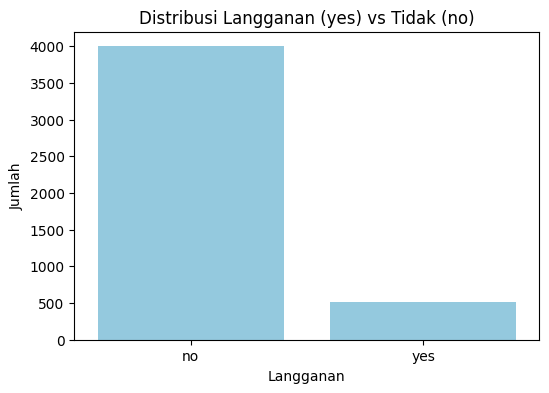

Jumlah Tidak Langganan (no)   : 4000 (88.5%)
Jumlah Langganan (yes)        : 521  (11.5%)


In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

#Visualisasi Jumlah Nilai Variabel Target
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, color='skyblue')
plt.title('Distribusi Langganan (yes) vs Tidak (no)')
plt.xlabel('Langganan')
plt.ylabel('Jumlah')
plt.show()

jumlah_no=(df['y']=='no').sum()
jumlah_yes=(df['y']=='yes').sum()
print(f"{'Jumlah Tidak Langganan (no)':<30}: {jumlah_no} ({(jumlah_no/df['y'].count())*100:.1f}%)")
print(f"{'Jumlah Langganan (yes)':<30}: {jumlah_yes}  ({(jumlah_yes/df['y'].count())*100:.1f}%)")

---
**INSIGHT 1: IMBALANCE DATA**

Berdasarkan visualisasi tersebut, dataset tidak seimbang (*imbalanced data*). Hal ini ditunjukkan oleh jumlah nilai `no` yang jauh lebih banyak (88.5%) dibandingkan nilai `yes` (11.5%). Jika dibiarkan, model akan sulit memprediksi nasabah yang akan berlangganan (`yes`) dan tidak dapat digeneralisasi.

---

####Fitur Numerik

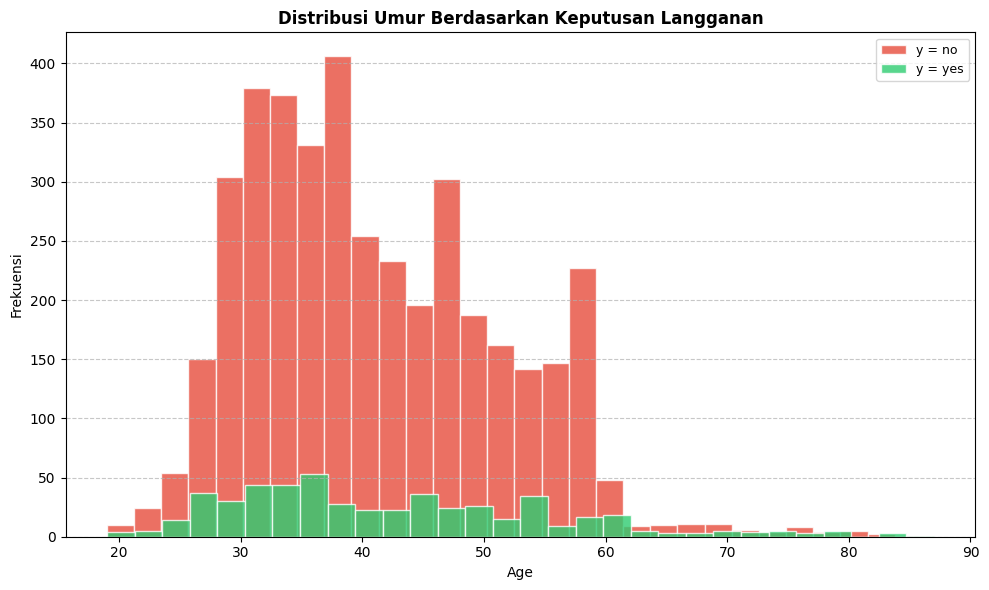

In [ ]:
#Visualisasi Distribusi Umur berdasarkan Variabel Target
plt.figure(figsize=(10, 6))

labels = ['no', 'yes']
colors = ['#e74c3c', '#2ecc71']

for i, label in enumerate(labels):
    plt.hist(df[df['y'] == label]['age'],
             bins=30,
             alpha=0.8,
             label=f'y = {label}',
             color=colors[i],
             edgecolor='white')
plt.title('Distribusi Umur Berdasarkan Keputusan Langganan',
            fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.xlabel('Age')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, rentang umur kebanyakan/mayoritas nasabah kampanye promosi ini berada pada **33 hingga 49 tahun** (sesuai Q1 dan Q3). Selain itu, terdapat beberapa data yang berada di area kanan (*right skewed*) yang menandakan nasabah yang berusia 60 hingga 80 tahun berjumlah sangat sedikit.

---

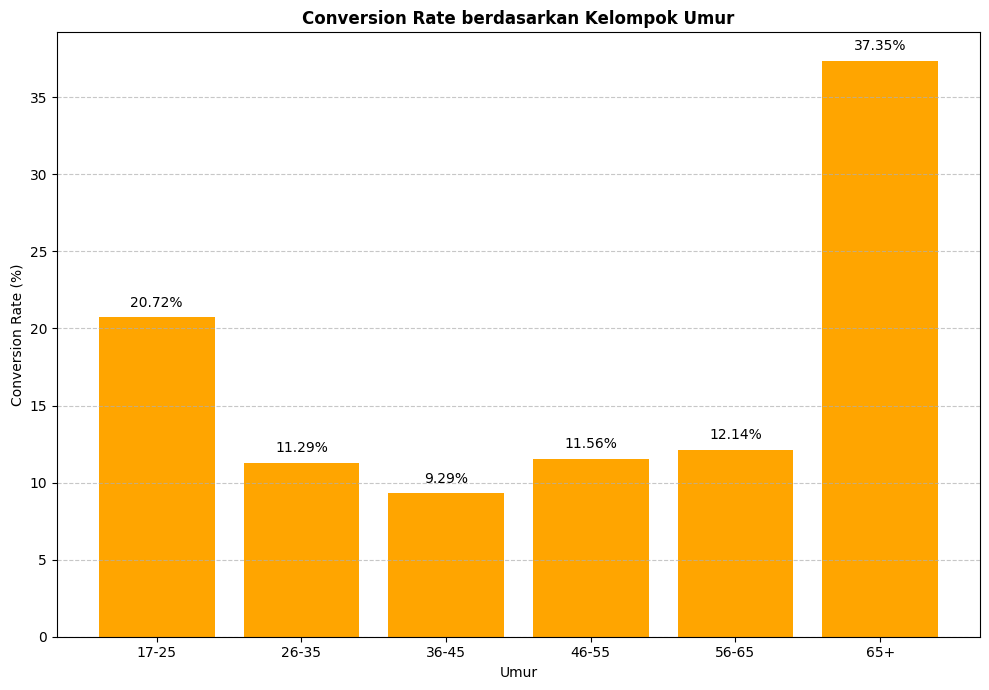

In [ ]:
#Visualisasi Conversion Rate Kelompok Umur
plt.figure(figsize=(10, 7))
df['age_group'] = pd.cut(df['age'], bins=[17,25,35,45,55,65,100],
                         labels=['17-25','26-35','36-45','46-55','56-65','65+'],
                         include_lowest=True)
age_category = df.groupby('age_group')['y'].agg(
    Conversion_Rate=(lambda x: (x == 'yes').mean()*100)
)

bars = plt.bar(age_category.index, age_category['Conversion_Rate'], color='orange')
plt.title('Conversion Rate berdasarkan Kelompok Umur', fontweight='bold')
plt.xlabel('Umur')
plt.ylabel('Conversion Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, nasabah dengan usia lebih dari 65 tahun (lansia dan pensiunan) memiliki tingkat konversi yang paling tinggi, meskipun jumlahnya sangat sedikit. Hal ini menandakan kelompok nasabah tersebut berpeluang tinggi untuk menerima tawaran deposito berjangka.

---

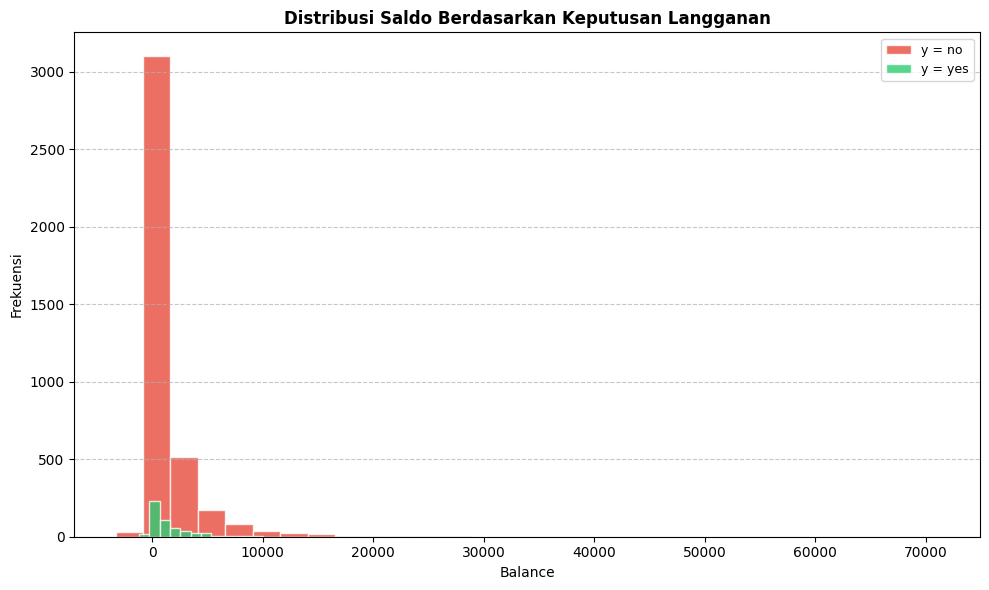

In [ ]:
#Visualisasi Distribusi Balance (Saldo) berdasarkan Variabel Target
plt.figure(figsize=(10, 6))

for i, label in enumerate(labels):
    plt.hist(df[df['y'] == label]['balance'],
             bins=30,
             alpha=0.8,
             label=f'y = {label}',
             color=colors[i],
             edgecolor='white')

plt.title('Distribusi Saldo Berdasarkan Keputusan Langganan',
            fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.xlabel('Balance')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
Bentuk distribusi tersebut sangat condong ke kanan (*right skewed*). Hal ini dapat diartikan, bahwa kebanyakan nasabah memiliki saldo mendekati 0 (sangat sedikit).

---


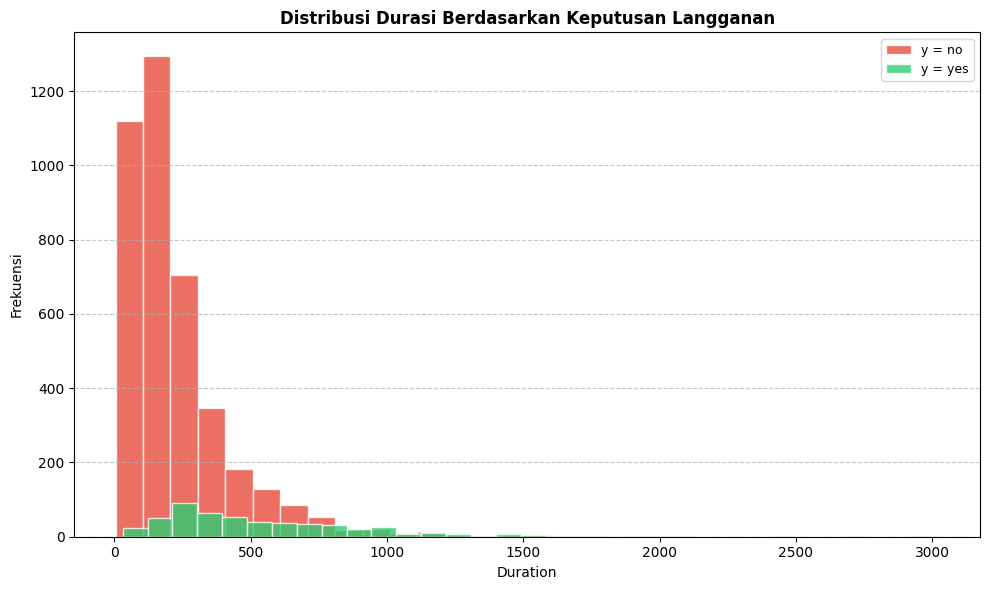

In [ ]:
#Visualisasi Distribusi Durasi berdasarkan Variabel Target
plt.figure(figsize=(10, 6))

for i, label in enumerate(labels):
    plt.hist(df[df['y'] == label]['duration'],
             bins=30,
             alpha=0.8,
             label=f'y = {label}',
             color=colors[i],
             edgecolor='white')

plt.title('Distribusi Durasi Berdasarkan Keputusan Langganan',
            fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.xlabel('Duration')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Rata-rata durasi (yes): {df[df['y'] == 'yes']['duration'].mean():.2f} detik")
print(f"Rata-rata durasi (no): {df[df['y'] == 'no']['duration'].mean():.2f} detik")

Rata-rata durasi (yes): 552.74 detik
Rata-rata durasi (no): 226.35 detik


---
Visualisasi tersebut berbentuk *right skewed*. Hal ini mengindikasikan bahwa durasi yang terlalu lama jarang terjadi atau nasabah lebih cenderung mengakhiri telepon dalam waktu yang cukup singkat. Selain itu, berdasarkan visualisasi tersebut, dapat disimpulkan bahwa nasabah yang menerima tawaran/berlangganan cenderung berbicara lebih lama. Pernyataan ini juga didukung oleh rata-rata durasi `yes` (berlangganan) yang lebih tinggi dibandingkan `no`.

---

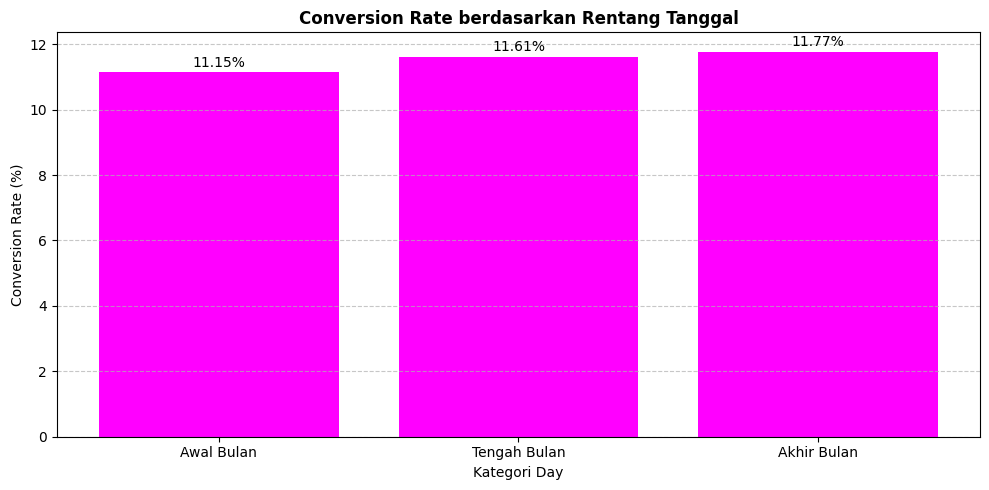

In [ ]:
#Visualisasi Conversion Rate Rentang Tanggal
plt.figure(figsize=(10, 5))
df['days_group'] = pd.cut(df['day'], bins=[1,10,20,31],
                         labels=['Awal Bulan','Tengah Bulan','Akhir Bulan'],
                         include_lowest=True)
day_category = df.groupby('days_group')['y'].agg(
    Conversion_Rate=(lambda x: (x == 'yes').mean()*100)
)

bars = plt.bar(day_category.index, day_category['Conversion_Rate'], color='magenta')
plt.title('Conversion Rate berdasarkan Rentang Tanggal', fontweight='bold')
plt.xlabel('Kategori Day')
plt.ylabel('Conversion Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%',
             ha='center', va='top')

plt.tight_layout()
plt.show()

---
Tanggal-tanggal dalam kolom `day` dipisahkan ke dalam 3 kategori, yatu `awal bulan` (1-10), `tengah bulan` (11-20), dan `akhir bulan` (21-31). Tujuannya agar proses memperoleh informasi mengenai karakteristik tanggal (`day`) nasabah menerima tawaran berlangganan dapat dilakukan dengan mudah dan sederhana. Berdasarkan hasil yang didapat, ketiga kategori memiliki tingkat konversi yang mirip/tidak jauh berbeda. Hal ini menunjukkan fitur `day` tidak terlalu mempengaruhi keputusan nasabah.

---

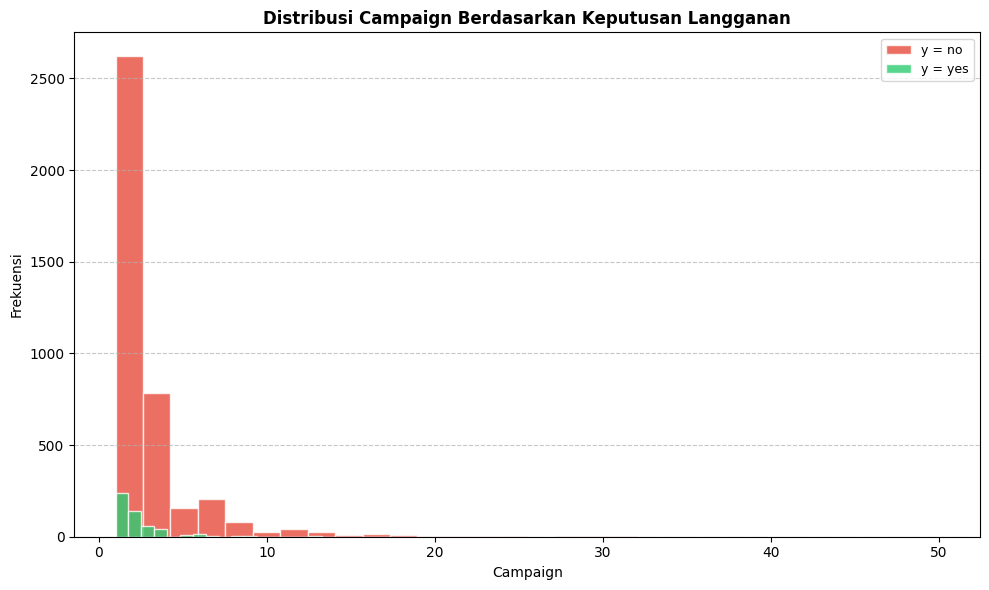

In [ ]:
#Visualisasi Distribusi Campaign (Frekuensi Kontak) berdasarkan Variabel Target
plt.figure(figsize=(10, 6))

for i, label in enumerate(labels):
    plt.hist(df[df['y'] == label]['campaign'],
             bins=30,
             alpha=0.8,
             label=f'y = {label}',
             color=colors[i],
             edgecolor='white')

plt.title('Distribusi Campaign Berdasarkan Keputusan Langganan',
            fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.xlabel('Campaign')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, kebanyakan nasabah memiliki jumlah `campaign` (frekuensi kontak/panggilan terhadap nasabah) yang sedikit. Hal ini dapat diartikan bahwa nasabah cenderung hanya akan menolak atau menerima tawaran di beberapa panggilan pertama saja (berdasarkan visualisasi, kurang dari 10 panggilan)

---

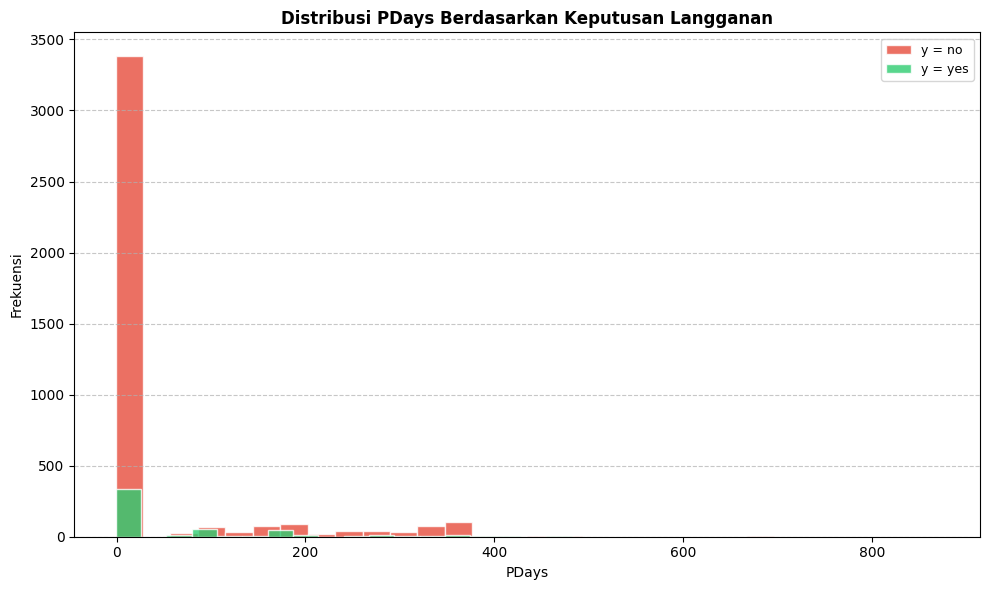

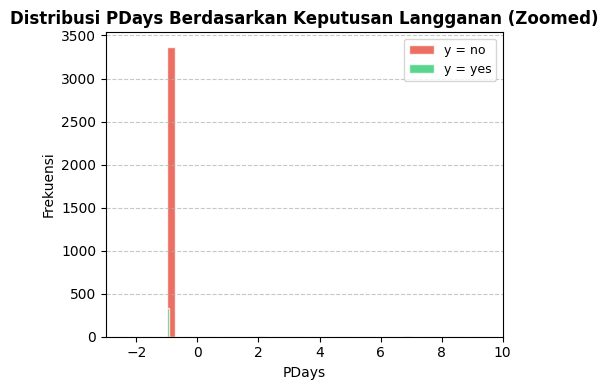

In [ ]:
#Visualisasi Distribusi pdays berdasarkan Variabel Target
plt.figure(figsize=(10, 6))

for i, label in enumerate(labels):
    plt.hist(df[df['y'] == label]['pdays'],
             bins=30,
             alpha=0.8,
             label=f'y = {label}',
             color=colors[i],
             edgecolor='white')

plt.title('Distribusi PDays Berdasarkan Keputusan Langganan',
            fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.xlabel('PDays')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#Memperkecil skala sumbu X agar memperlihatkan ada value -1
plt.figure(figsize=(5, 4))
for i, label in enumerate(labels):
    plt.hist(df[(df['y'] == label)&(df['pdays']<10)]['pdays'],
             bins=30,
             alpha=0.8,
             label=f'y = {label}',
             color=colors[i],
             edgecolor='white')
plt.xlim(-3, 10)
plt.title('Distribusi PDays Berdasarkan Keputusan Langganan (Zoomed)',
          fontsize=12, fontweight='bold')
plt.xlabel('PDays')
plt.ylabel('Frekuensi')
plt.legend(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, mayoritas nasabah **tidak pernah dihubungi** pada masa kampanye sebelumnya (nilai -1 menandakan tidak pernah dihubungi sebelumnya).

---

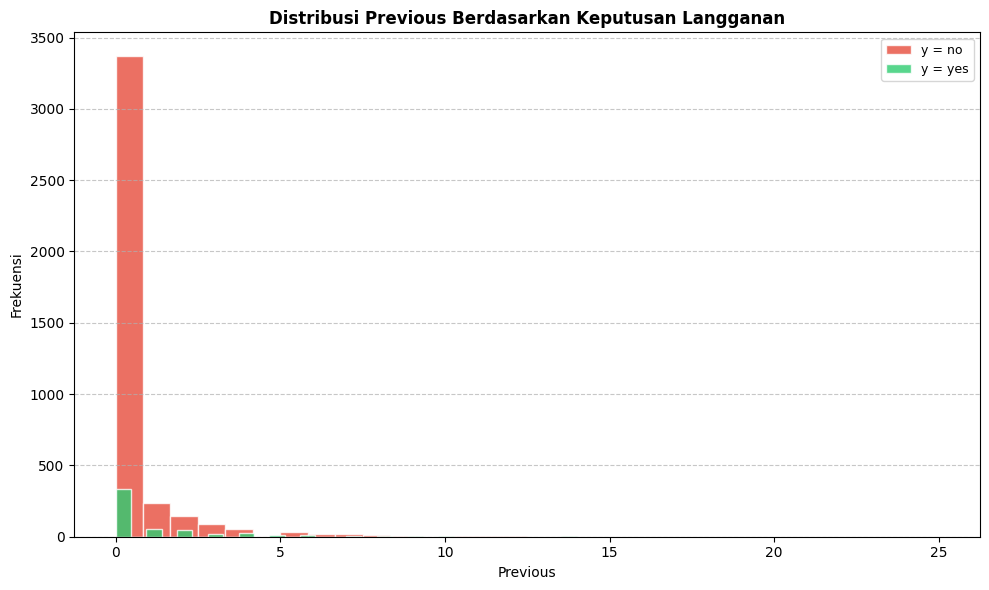

In [ ]:
#Visualisasi Distribusi Previous (Jumlah Kontak Campaign Sebelumnya) berdasarkan Variabel Target
plt.figure(figsize=(10, 6))

for i, label in enumerate(labels):
    plt.hist(df[df['y'] == label]['previous'],
             bins=30,
             alpha=0.8,
             label=f'y = {label}',
             color=colors[i],
             edgecolor='white')

plt.title('Distribusi Previous Berdasarkan Keputusan Langganan',
            fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.xlabel('Previous')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, mayoritas nasabah pada kampanye sebelumnya **jarang** dihubungi (frekuensi kontak/panggilannya kecil). Bentuk distribusinya cenderung menyerupai `campaign` (frekuensi kontak/panggilan pada kampanye saat ini).

---

---
**INSIGHT 2: DISTRIBUSI DATA NUMERIK**

1. `Demografi Usia`: Mayoritas nasabah berada pada rentang usia **33 hingga 49 tahun** dan nasabah yang berusia lebih dari **65 tahun** memiliki tingkat konversi paling tinggi.
2. `Finansial Nasabah`: Kebanyakan nasabah yang menerima, maupun menolak tawaran memiliki saldo mendekati 0 (sangat sedikit)
3. `Karakteristik Durasi`: Nasabah yang menerima tawaran/berlangganan **cenderung berbicara lebih lama**.
4. `Rentang Tanggal`: Tanggal saat nasabah dihubungi **tidak terlalu berpengaruh** terhadap keputusan nasabah.
4. `Kecenderungan Respon`: Kebanyakan nasabah menolak atau menerima tawaran **kurang dari 10 panggilan pertama**.
5. `Data Historis`: Mayoritas nasabah **belum pernah/jarang dihubungi** pada periode kampanye sebelumnya.

---

####Fitur Kategorik

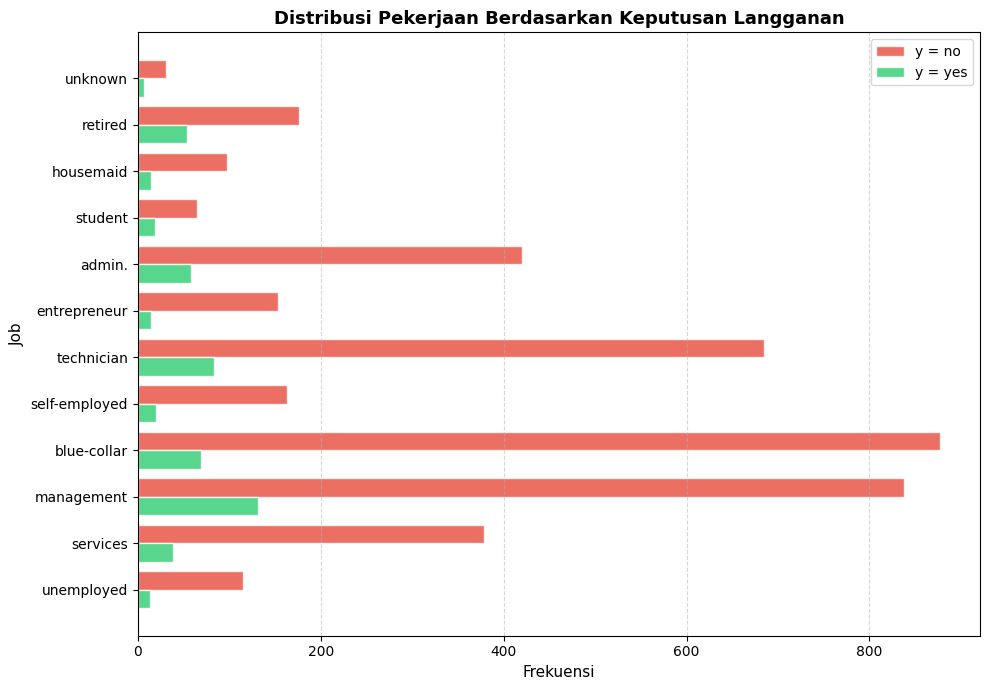

In [ ]:
#Visualisasi Distribusi Kategori Job berdasarkan Variabel Target
plt.figure(figsize=(10, 7))

job_categories = df['job'].unique()
yes_counts = [len(df[(df['job'] == job) & (df['y'] == 'yes')]) for job in job_categories]
no_counts  = [len(df[(df['job'] == job) & (df['y'] == 'no')]) for job in job_categories]

y_index   = np.arange(len(job_categories))
bar_height   = 0.4

bars_no  = plt.barh(y_index + bar_height/2, no_counts,  height=bar_height, color=colors[0],
                    label='y = no',  edgecolor='white', alpha=0.8)
bars_yes = plt.barh(y_index - bar_height/2, yes_counts, height=bar_height, color=colors[1],
                    label='y = yes', edgecolor='white', alpha=0.8)

plt.yticks(y_index, job_categories, fontsize=10)
plt.xlabel('Frekuensi', fontsize=11)
plt.ylabel('Job', fontsize=11)
plt.title('Distribusi Pekerjaan Berdasarkan Keputusan Langganan',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, mayoritas nasabah yang terlibat dalam kampanye ini bekerja di bagian `manajemen`, `blue-collar` (pekerjaan dengan tenaga fisik), dan `technician`.

---

In [ ]:
#Perhitungan Conversion Rate
tabel_konversi = df.groupby('job')['y'].agg(
    Total_Nasabah='count',
    Total_Konversi=lambda x: (x == 'yes').sum(),
    Conversion_Rate=lambda x: (x == 'yes').mean()
).reset_index().sort_values(by='Conversion_Rate', ascending=False, ignore_index=True)

tabel_konversi['Conversion_Rate'] = (tabel_konversi['Conversion_Rate'] * 100).round(2).astype(str) + '%'

tabel_konversi

,job,Total_Nasabah,Total_Konversi,Conversion_Rate
0,retired,230,54,23.48%
1,student,84,19,22.62%
2,unknown,38,7,18.42%
3,management,969,131,13.52%
4,housemaid,112,14,12.5%
5,admin.,478,58,12.13%
6,self-employed,183,20,10.93%
7,technician,768,83,10.81%
8,unemployed,128,13,10.16%
9,services,417,38,9.11%


---
Berdasarkan perhitungan *Conversion Rate* tersebut, nasabah yang **pensiun** dan **pelajar** tingkat konversinya paling tinggi. Artinya, peluang nasabah pelajar dan yang telah pensiun untuk menerima tawaran deposito berjangka lebih tinggi.

---

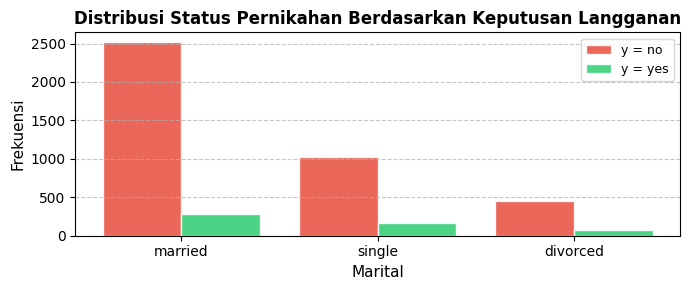

In [ ]:
#Visualisasi distribusi marital status berdasarkan variabel target
plt.figure(figsize=(7, 3))

marital_categories = df['marital'].unique()
yes_counts = [len(df[(df['marital'] == status) & (df['y'] == 'yes')]) for status in marital_categories]
no_counts  = [len(df[(df['marital'] == status) & (df['y'] == 'no')]) for status in marital_categories]

x_index  = np.arange(len(marital_categories))
bar_width  = 0.4

plt.bar(x_index - bar_width/2, no_counts,  width=bar_width, color=colors[0],
        label='y = no',  edgecolor='white', alpha=0.85)
plt.bar(x_index + bar_width/2, yes_counts, width=bar_width, color=colors[1],
        label='y = yes', edgecolor='white', alpha=0.85)

plt.xticks(x_index, marital_categories, fontsize=10)
plt.xlabel('Marital', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('Distribusi Status Pernikahan Berdasarkan Keputusan Langganan',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, mayoritas nasabah yang terlibat dalam kampanye promosi **sudah menikah**.

---

In [ ]:
#Perhitungan Conversion Rate
tabel_konversi = df.groupby('marital')['y'].agg(
    Total_Nasabah='count',
    Total_Konversi=lambda x: (x == 'yes').sum(),
    Conversion_Rate=lambda x: (x == 'yes').mean()
).reset_index().sort_values(by='Conversion_Rate', ascending=False, ignore_index=True)

tabel_konversi['Conversion_Rate'] = (tabel_konversi['Conversion_Rate'] * 100).round(2).astype(str) + '%'

tabel_konversi

,marital,Total_Nasabah,Total_Konversi,Conversion_Rate
0,divorced,528,77,14.58%
1,single,1196,167,13.96%
2,married,2797,277,9.9%


---
Berdasarkan perhitungan *Conversion Rate* tersebut, tingkat konversi tertinggi diperoleh oleh kategori status pernikahan yang telah cerai (`divorced`) dan masih sendiri (`single`). Hal ini bertolak belakang dengan informasi jumlah nasabah pada bagian sebelumnya, dimana mayoritas nasabah telah menikah (`married`). Penyebabnya dapat diasumsikan, bahwa nasabah yang telah menikah memiliki beban keuangan yang lebih, sehingga sulit untuk menerima tawaran deposito berjangka.

---

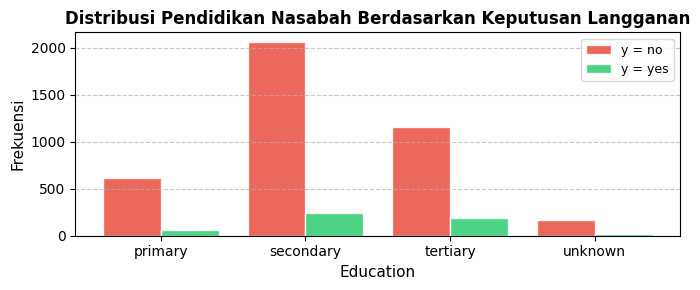

In [ ]:
#Visualisasi distribusi education berdasarkan variabel target
plt.figure(figsize=(7, 3))

education_categories = df['education'].unique()
yes_counts = [len(df[(df['education'] == i) & (df['y'] == 'yes')]) for i in education_categories]
no_counts  = [len(df[(df['education'] == i) & (df['y'] == 'no')]) for i in education_categories]

x_index  = np.arange(len(education_categories))
bar_width  = 0.4

plt.bar(x_index - bar_width/2, no_counts,  width=bar_width, color=colors[0],
        label='y = no',  edgecolor='white', alpha=0.85)
plt.bar(x_index + bar_width/2, yes_counts, width=bar_width, color=colors[1],
        label='y = yes', edgecolor='white', alpha=0.85)

plt.xticks(x_index, education_categories, fontsize=10)
plt.xlabel('Education', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('Distribusi Pendidikan Nasabah Berdasarkan Keputusan Langganan',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, mayoritas nasabah menempuh pendidikan terakhir, yaitu `secondary` (SMA).

---

In [ ]:
#Perhitungan Conversion Rate
tabel_konversi = df.groupby('education')['y'].agg(
    Total_Nasabah='count',
    Total_Konversi=lambda x: (x == 'yes').sum(),
    Conversion_Rate=lambda x: (x == 'yes').mean()
).reset_index().sort_values(by='Conversion_Rate', ascending=False, ignore_index=True)

tabel_konversi['Conversion_Rate'] = (tabel_konversi['Conversion_Rate'] * 100).round(2).astype(str) + '%'

tabel_konversi

,education,Total_Nasabah,Total_Konversi,Conversion_Rate
0,tertiary,1350,193,14.3%
1,secondary,2306,245,10.62%
2,unknown,187,19,10.16%
3,primary,678,64,9.44%


---
Berdasarkan perhitungan *Conversion Rate* tersebut, nasabah dengan pendidikan `tertiary` berpeluang lebih tinggi menerima tawaran untuk berlangganan deposito berjangka.

---

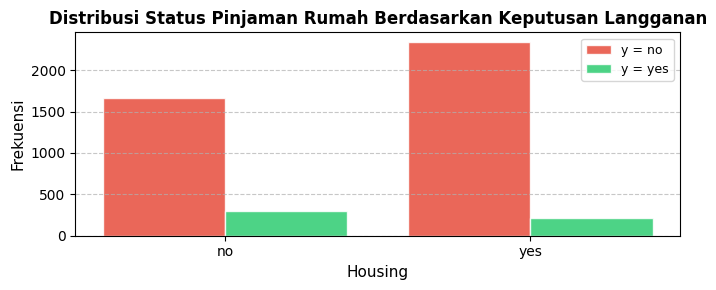

In [ ]:
#Visualisasi distribusi housing (pinjaman rumah) berdasarkan variabel target
plt.figure(figsize=(7, 3))

housing_categories = df['housing'].unique()
yes_counts = [len(df[(df['housing'] == i) & (df['y'] == 'yes')]) for i in housing_categories]
no_counts  = [len(df[(df['housing'] == i) & (df['y'] == 'no')]) for i in housing_categories]

x_index  = np.arange(len(housing_categories))
bar_width  = 0.4

plt.bar(x_index - bar_width/2, no_counts,  width=bar_width, color=colors[0],
        label='y = no',  edgecolor='white', alpha=0.85)
plt.bar(x_index + bar_width/2, yes_counts, width=bar_width, color=colors[1],
        label='y = yes', edgecolor='white', alpha=0.85)

plt.xticks(x_index, housing_categories, fontsize=10)
plt.xlabel('Housing', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('Distribusi Status Pinjaman Rumah Berdasarkan Keputusan Langganan',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, mayoritas nasabah sedang melakukan peminjaman rumah (Kredit Pemilikan Rumah (KPR)).

---

In [ ]:
#Perhitungan Conversion Rate
tabel_konversi = df.groupby('housing')['y'].agg(
    Total_Nasabah='count',
    Total_Konversi=lambda x: (x == 'yes').sum(),
    Conversion_Rate=lambda x: (x == 'yes').mean()
).reset_index().sort_values(by='Conversion_Rate', ascending=False, ignore_index=True)

tabel_konversi['Conversion_Rate'] = (tabel_konversi['Conversion_Rate'] * 100).round(2).astype(str) + '%'

tabel_konversi

,housing,Total_Nasabah,Total_Konversi,Conversion_Rate
0,no,1962,301,15.34%
1,yes,2559,220,8.6%


---
Perhitungan *Conversion Rate* menunjukkan nasabah yang tidak memiliki pinjaman rumah (KPR) lebih mungkin/berpeluang untuk menerima tawaran langganan deposito berjangka. Secara logis, nasabah yang tidak memiliki beban pinjaman rumah (KPR) memiliki dana/keuangan yang tidak tertekan oleh cicilan.

---

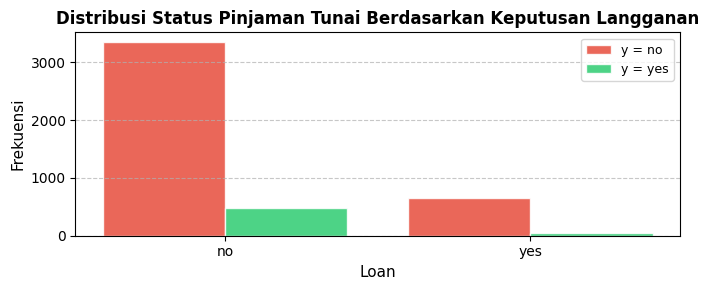

In [ ]:
#Visualisasi distribusi pinjaman (loan) berdasarkan variabel target
plt.figure(figsize=(7, 3))

loan_categories = df['loan'].unique()
yes_counts = [len(df[(df['loan'] == i) & (df['y'] == 'yes')]) for i in loan_categories]
no_counts  = [len(df[(df['loan'] == i) & (df['y'] == 'no')]) for i in loan_categories]

x_index  = np.arange(len(loan_categories))
bar_width  = 0.4

plt.bar(x_index - bar_width/2, no_counts,  width=bar_width, color=colors[0],
        label='y = no',  edgecolor='white', alpha=0.85)
plt.bar(x_index + bar_width/2, yes_counts, width=bar_width, color=colors[1],
        label='y = yes', edgecolor='white', alpha=0.85)

plt.xticks(x_index, loan_categories, fontsize=10)
plt.xlabel('Loan', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('Distribusi Status Pinjaman Tunai Berdasarkan Keputusan Langganan',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, kebanyakan nasabah tidak memiliki pinjaman tunai.

---

In [ ]:
#Perhitungan Conversion Rate
tabel_konversi = df.groupby('loan')['y'].agg(
    Total_Nasabah='count',
    Total_Konversi=lambda x: (x == 'yes').sum(),
    Conversion_Rate=lambda x: (x == 'yes').mean()
).reset_index().sort_values(by='Conversion_Rate', ascending=False, ignore_index=True)

tabel_konversi['Conversion_Rate'] = (tabel_konversi['Conversion_Rate'] * 100).round(2).astype(str) + '%'

tabel_konversi

,loan,Total_Nasabah,Total_Konversi,Conversion_Rate
0,no,3830,478,12.48%
1,yes,691,43,6.22%


---
Perhitungan *Conversion Rate* menunjukkan tingkat konversi nasabah yang tidak memiliki pinjaman tunai lebih tinggi. Hal ini sesuai jika dilihat dari sisi finansial, karena nasabah tanpa beban pinjaman akan memiliki alokasi dana yang lebih bebas.

---

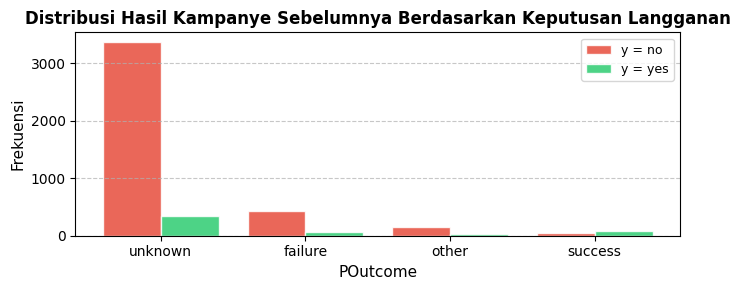

In [ ]:
#Visualisasi distribusi Hasil Kampanye Sebelumnya berdasarkan variabel target
plt.figure(figsize=(7, 3))

poutcome_categories = df['poutcome'].unique()
yes_counts = [len(df[(df['poutcome'] == i) & (df['y'] == 'yes')]) for i in poutcome_categories]
no_counts  = [len(df[(df['poutcome'] == i) & (df['y'] == 'no')]) for i in poutcome_categories]

x_index  = np.arange(len(poutcome_categories))
bar_width  = 0.4

plt.bar(x_index - bar_width/2, no_counts,  width=bar_width, color=colors[0],
        label='y = no',  edgecolor='white', alpha=0.85)
plt.bar(x_index + bar_width/2, yes_counts, width=bar_width, color=colors[1],
        label='y = yes', edgecolor='white', alpha=0.85)

plt.xticks(x_index, poutcome_categories, fontsize=10)
plt.xlabel('POutcome', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('Distribusi Hasil Kampanye Sebelumnya Berdasarkan Keputusan Langganan',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
Sesuai dengan informasi distribusi fitur `pdays` sebelumnya, bahwa mayoritas nasabah yang terlibat dalam kampanye ini belum pernah dihubungi pada kampanye sebelumnya.

---

In [ ]:
#Perhitungan Conversion Rate
tabel_konversi = df.groupby('poutcome')['y'].agg(
    Total_Nasabah='count',
    Total_Konversi=lambda x: (x == 'yes').sum(),
    Conversion_Rate=lambda x: (x == 'yes').mean()
).reset_index().sort_values(by= 'Conversion_Rate', ascending= False, ignore_index= True)

tabel_konversi['Conversion_Rate'] = (tabel_konversi['Conversion_Rate'] * 100).round(2).astype(str) + '%'

tabel_konversi

,poutcome,Total_Nasabah,Total_Konversi,Conversion_Rate
0,success,129,83,64.34%
1,other,197,38,19.29%
2,failure,490,63,12.86%
3,unknown,3705,337,9.1%


---
Nasabah yang menerima tawaran deposito pada periode kampanye sebelumnya memiliki tingkat konversi yang paling tinggi. Hal ini mengindikasikan bahwa sebagian nasabah yang menerima tawaran pada periode kampanye sebelumnya tetap memperbarui/menambah akun deposito baru (loyal).

---

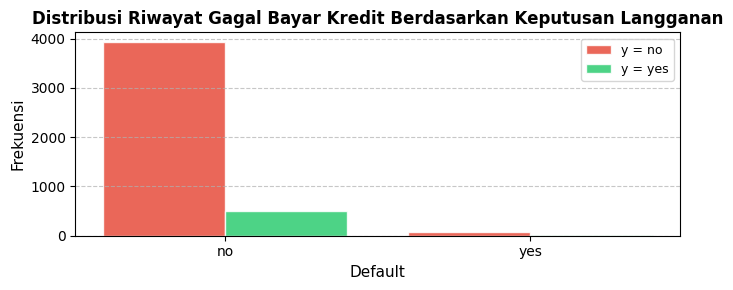

In [ ]:
#Visualisasi distribusi Riwayat Gagal Bayar Kredit berdasarkan variabel target
plt.figure(figsize=(7, 3))

default_categories = df['default'].unique()
yes_counts= [len(df[(df['default'] == i) & (df['y'] == 'yes')]) for i in default_categories]
no_counts= [len(df[(df['default'] == i) & (df['y'] == 'no')]) for i in default_categories]

x_index  = np.arange(len(default_categories))
bar_width  = 0.4

plt.bar(x_index - bar_width/2, no_counts,  width=bar_width, color=colors[0],
        label='y = no',  edgecolor='white', alpha=0.85)
plt.bar(x_index + bar_width/2, yes_counts, width=bar_width, color=colors[1],
        label='y = yes', edgecolor='white', alpha=0.85)

plt.xticks(x_index, default_categories, fontsize=10)
plt.xlabel('Default', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('Distribusi Riwayat Gagal Bayar Kredit Berdasarkan Keputusan Langganan',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, mayoritas nasabah tidak memiliki riwayat gagal bayar kredit (bersih).

---

In [ ]:
#Perhitungan Conversion Rate
tabel_konversi = df.groupby('default')['y'].agg(
    Total_Nasabah='count',
    Total_Konversi=lambda x: (x == 'yes').sum(),
    Conversion_Rate=lambda x: (x == 'yes').mean()
).reset_index().sort_values(by= 'Conversion_Rate', ascending= False, ignore_index= True)

tabel_konversi['Conversion_Rate'] = (tabel_konversi['Conversion_Rate'] * 100).round(2).astype(str) + '%'

tabel_konversi

,default,Total_Nasabah,Total_Konversi,Conversion_Rate
0,yes,76,9,11.84%
1,no,4445,512,11.52%


---
Tingkat konversi kedua kategori (memiliki riwayat gagal bayar kredit dan tidak) tidak berbeda jauh. Hal ini menunjukkan, bahwa fitur `default` tidak terlalu berpengaruh terhadap keputusan nasabah (variabel target).

---

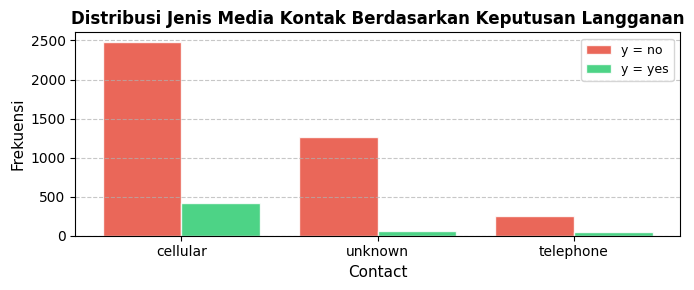

In [ ]:
#Visualisasi distribusi jenis media yang digunakan untuk menghubungi nasabah berdasarkan variabel target
plt.figure(figsize=(7, 3))

contact_categories = df['contact'].unique()
yes_counts = [len(df[(df['contact'] == i) & (df['y'] == 'yes')]) for i in contact_categories]
no_counts  = [len(df[(df['contact'] == i) & (df['y'] == 'no')]) for i in contact_categories]

x_index  = np.arange(len(contact_categories))
bar_width  = 0.4

plt.bar(x_index - bar_width/2, no_counts,  width=bar_width, color=colors[0],
        label='y = no',  edgecolor='white', alpha=0.85)
plt.bar(x_index + bar_width/2, yes_counts, width=bar_width, color=colors[1],
        label='y = yes', edgecolor='white', alpha=0.85)

plt.xticks(x_index, contact_categories, fontsize=10)
plt.xlabel('Contact', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('Distribusi Jenis Media Kontak Berdasarkan Keputusan Langganan',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, mayoritas nasabah dihubungi menggunakan telepon seluler (ponsel genggam). Sehingga, departemen pemasaran bisa memberikan perhatian lebih dalam mengoptimalkan strategi penawaran melalui ponsel seluler. Namun, penggalian informasi mengenai *conversion rate* setiap media perlu dilakukan sebelum mengambil keputusan.

---

In [ ]:
#Perhitungan conversion rate
tabel_konversi = df.groupby('contact')['y'].agg(
    Total_Nasabah='count',
    Total_Sukses=lambda x: (x == 'yes').sum(),
    Conversion_Rate=lambda x: (x == 'yes').mean()
).reset_index().sort_values(by='Conversion_Rate', ascending= False, ignore_index= False)

tabel_konversi['Conversion_Rate'] = (tabel_konversi['Conversion_Rate'] * 100).round(2).astype(str) + '%'

tabel_konversi

,contact,Total_Nasabah,Total_Sukses,Conversion_Rate
1,telephone,301,44,14.62%
0,cellular,2896,416,14.36%
2,unknown,1324,61,4.61%


---
Berdasarkan perhitungan *conversion rate*, media `telephone` memiliki tingkat conversi yang lebih tinggi dibandingkan `cellular`. Hal ini membuktikan bahwa meskipun volume/jumlah nasabah yang dihubungi melalui ponsel telepon seluler jauh lebih banyak, tetapi nasabah yang dihubungi melalui telepon biasa memiliki tingkat keberhasilan penawaran yang lebih tinggi. Sehingga, departemen pemasaran tidak boleh langsung menghilangkan media telepon sebagai salah satu media kontak.

---

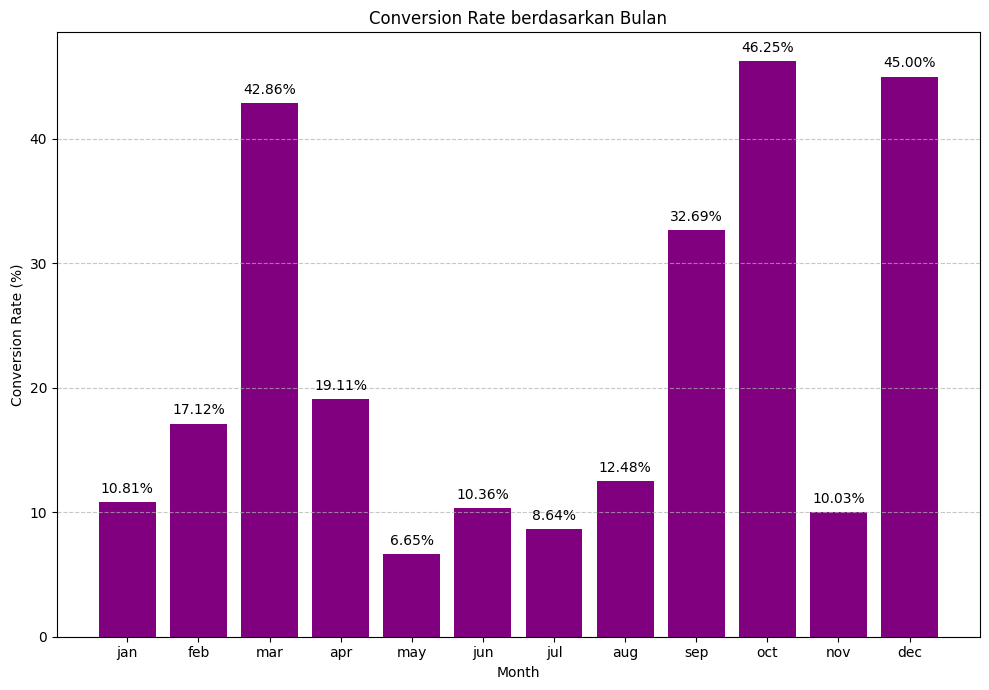

In [ ]:
#Visualisasi Tingkat Konversi Per Bulan
plt.figure(figsize=(10, 7))

month = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

month_conversion = df.groupby('month')['y'].agg(
    Conversion_Rate=(lambda x: (x == 'yes').mean() * 100)
).reindex(month, level='month')

bars = plt.bar(month_conversion.index, month_conversion['Conversion_Rate'], color='purple')
plt.title('Conversion Rate berdasarkan Bulan')
plt.xlabel('Month')
plt.ylabel('Conversion Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

---
Berdasarkan visualisasi tersebut, nasabah paling banyak menerima tawaran pada bulan **Oktober**, **Desember**, dan **Maret**. Hal ini kemungkinan disebabkan oleh momentum releksi akhir tahun atau awal tahun untuk melakukan evaluasi keuangan. Hal ini memancing keinginan nasabah untuk menyimpan uangnya dalam instrumen tertentu, seperti deposito berjangka.

---
*Note: Distribusi bulanan berdasarkan variabel target tidak dilakukan karena informasi yang didapatkan tidak terlalu penting.

---
**INSIGHT 3: DISTRIBUSI FITUR KATEGORIK**

1. `Tipe Pekerjaan`: Nasabah yang sudah pensiun (`retired`) dan masih pelajar (`student`) lebih tinggi peluangnya dalam menerima tawaran.

2. `Status Pernikahan`: Mayoritas nasabah sudah menikah, namun nasabah yang tidak memiliki pasangan (`single/divorced`) lebih berpeluang unuk menerima tawaran langganan deposito berjangka.

3. `Tingkat Pendidikan`: Nasabah dengan pendidikan di atas SMA (`tertiary`) berpeluang lebih tinggi untuk berlangganan.

4. `Pengaruh Housing`: Nasabah yang **tidak sedang memiliki tanggungan KPR/pinjaman rumah** lebih berpeluang untuk menerima tawaran.

5. `Pengaruh Loan`: Nasabah yang **tidak memiliki beban pinjaman tunai** lebih berpeluang untuk menerima tawaran.

6. `Previous Outcome`: Terdapat cukup banyak nasabah yang **menambah/memperbarui** langganan deposito berjangkanya.

7. `Pengaruh Default`: Faktor **default** tidak berpengaruh pada keputusan nasabah dalam berlangganan.

8. `Media Kontak`: Media **telepon** tetap perlu dipertahankan karena memiliki tingkat konversi yang tinggi, meskipun jumlahnya berbeda jauh dari **cellular**.

9. `Momentum Bulan`: Tingkat konversi (penerimaan tawaran) tertinggi terdapat pada bulan **Oktober**, **Desember**, dan **Maret**.

---

###Korelasi Fitur-fitur

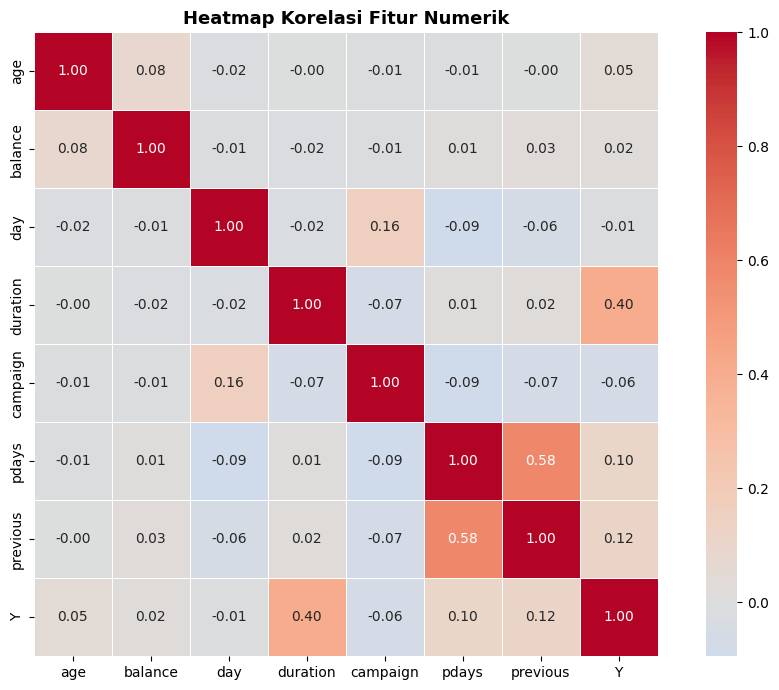

In [ ]:
#Visualisasi Heatmap Korelasi antar fitur
num_cols = df.select_dtypes(include=['int64']).columns.tolist()
fig, ax = plt.subplots(figsize=(10, 7))
#Perhitungan korelasi
corr = df[num_cols + ['y']].copy()
corr['Y'] = (corr['y'] == 'yes').astype(int) #Label Encoding untuk Y
corr = corr.drop('y', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
**INSIGHT 4: FITUR YANG PALING BERKORELASI**

Berdasarkan visualisasi heatmap tersebut, fitur `'y'` sangat berkorelasi dengan fitur `duration`. Hal ini juga dibuktikan pada diagram distribusi **durasi** berdasarkan variabel target, dimana nasabah yang berlangganan cenderung akan melakukan panggilan dengan durasi yang cukup **lama**.

---

## **Metodologi**
---
### Data Preprocessing
---

**Langkah preprocessing:**
1. **Copy Data**: menyalin **dataframe mentah** sebagai **dataframe preprocessing**.
2. **Feature Selection**: hapus fitur `day`, `default`, `age_group`, dan `days_group` dari dataframe.
3. **Label Encoding** untuk fitur kategorik-> (`housing`, `loan`, `y`).
4. **Ordinal Encoding** untuk fitur kategorik-> (`education`, `month`).
5. **One-Hot Encoding** untuk fitur kategorik-> (`job`, `marital`, `contact`, `poutcome`).
6. **Robust Scaler** untuk fitur numerik (karena kebanyakan distribusinya cenderung tidak normal (*skewed*)).
7. **class_weight balanced** untuk menangani **imbalanced data** (diatur pada parameter model).

*Setiap langkah akan dibuat dalam satu fungsi agar dapat digunakan masing-masing untuk **train_pool** dan **personal_test** data. Namun, setiap prosesnya akan dipaparkan secara terpisah terlebih dahulu.*

---
### Data Modelling

---

**Model yang digunakan:**
1. **Model 1:** Decision Tree Classifier (ensemble model)
2. **Model 2:** Random Forest Classifier (ensemble model)
3. **Model 3:** Extreme Gradient Boosting (ensemble model)

**Tuning:** `GridSearchCV` dengan 3-fold Stratified Cross Validation

---
### Evaluasi

---
1. **Classification Report** meliputi akurasi, precision, recall, dan f1-score.
2. **Confusion Matrix** untuk melihat hasil dan performa prediksi model.
3. **ROC-AUC** untuk mengukur kemampuan model mengklasifikasikan 2 kelas.
4. **PR-AUC** digunakan karena data yang digunakan sangat tidak seimbang, metrik ini berfokus pada kemampuan model memprediksi kelas positif sehingga sangat penting apabila berhadapan dengan kasus *imbalance data*.

---
###Alasan

---
- Alasan fitur `education` diencoding dengan **ordinal encoding** karena secara alami memiliki urutan/tingkatan. Selain itu, model yang digunakan adalah *tree based model*, sehingga tidak terpengaruh oleh asumsi urutan (nilai unknown dijadikan 0 atau 1, tidak akan terlalu berpengaruh).
- Alasan fitur `month` diencode menggunakan **ordinal encoding** karena jika menggunakan **One-Hot Encoding** akan menghasilkan terlalu banyak fitur. Selain itu, model yang digunakan bukan model linear seperti *logistic regression*. Sehingga beberapa nilai aneh, seperti **-1** pada fitur `pdays` tidak diubah.
- Alasan model yang digunakan hanyalah **model ensemble** dan bukan **linear classification** seperti `logistic regression` karena performa **model ensemble**, seperti `Random Forest`, `XGBoost`, dan sebagainya lebih baik dalam klasifikasi (Chian et al., 2024).
- Alasan tuning menggunakan **GridSearchCV** untuk mendapatkan parameter yang paling optimal secara keseluruhan. Untuk mengatasi masalah waktu yang terlalu lama, rentang parameter yang diuji telah dibatasi.
- Alasan pemilihan **Stratified K-Fold** karena ia cocok digunakan untuk model **klasifikasi** dan menghadapi **dataset yang tidak seimbang** (*imbalance*). Ia memastikan model mendapatkan data dari setiap kelas (model dijamin mendapatkan data yes dan no, tidak hanya no) (Chihaoui et al., 2026).
- Alasan nilai K yang digunakan adalah 3 dan pilihan parameter yang digunakan tidak terlalu banyak, karena untuk menghemat **durasi running** dan **resources**.

###**Data Preprocessing**

In [ ]:
#Membuat salinan df untuk memisahkan data mentahan dan preprocessed
df_prep = df.copy()

####Feature Selection

In [ ]:
kolom=df_prep.columns.tolist()
kolom

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y',
 'age_group',
 'days_group']

---
Kolom `day` dan `default` tidak diperlukan dalam proses pemodelan, karena tidak memberikan makna signifikan bagi model, sehingga dapat dihapus agar model dapat menangkap pola data dengan mudah.

Tidak lupa juga untuk menghapus `age_group` dan `days_group`.

---


In [ ]:
#Penghapusan fitur
df_prep=df_prep.drop(['day','default','age_group','days_group'], axis=1)
df_prep.head()

,age,job,marital,education,balance,housing,loan,contact,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,1787,no,no,cellular,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,4789,yes,yes,cellular,may,220,1,339,4,failure,no
2,35,management,single,tertiary,1350,yes,no,cellular,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,1476,yes,yes,unknown,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,0,yes,no,unknown,may,226,1,-1,0,unknown,no


####Data Encoding

In [ ]:
#Ambil Kolom Kategorik yes/no
yesno_cols=['housing', 'loan', 'y']

#Label Encoding
df_prep[yesno_cols]=df_prep[yesno_cols].replace({'yes':1, 'no':0})
df_prep.head()

,age,job,marital,education,balance,housing,loan,contact,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,1787,0,0,cellular,oct,79,1,-1,0,unknown,0
1,33,services,married,secondary,4789,1,1,cellular,may,220,1,339,4,failure,0
2,35,management,single,tertiary,1350,1,0,cellular,apr,185,1,330,1,failure,0
3,30,management,married,tertiary,1476,1,1,unknown,jun,199,4,-1,0,unknown,0
4,59,blue-collar,married,secondary,0,1,0,unknown,may,226,1,-1,0,unknown,0


In [ ]:
#Ordinal Encoding
df_prep['education']=df_prep['education'].replace({'unknown':0, 'primary':1, 'secondary':2, 'tertiary':3})
df_prep['month']=df_prep['month'].replace({'jan':0, 'feb':1, 'mar':2, 'apr':3, 'may':4, 'jun':5, 'jul':6, 'aug':7, 'sep':8, 'oct':9, 'nov':10, 'dec':11})
df_prep.head()

,age,job,marital,education,balance,housing,loan,contact,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,1,1787,0,0,cellular,9,79,1,-1,0,unknown,0
1,33,services,married,2,4789,1,1,cellular,4,220,1,339,4,failure,0
2,35,management,single,3,1350,1,0,cellular,3,185,1,330,1,failure,0
3,30,management,married,3,1476,1,1,unknown,5,199,4,-1,0,unknown,0
4,59,blue-collar,married,2,0,1,0,unknown,4,226,1,-1,0,unknown,0


In [ ]:
#One Hot Encoding
df_encoded=pd.get_dummies(df_prep, drop_first=True)
df_encoded.head()

,age,education,balance,housing,loan,month,duration,campaign,pdays,previous,...,job_technician,job_unemployed,job_unknown,marital_married,marital_single,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,30,1,1787,0,0,9,79,1,-1,0,...,False,True,False,True,False,False,False,False,False,True
1,33,2,4789,1,1,4,220,1,339,4,...,False,False,False,True,False,False,False,False,False,False
2,35,3,1350,1,0,3,185,1,330,1,...,False,False,False,False,True,False,False,False,False,False
3,30,3,1476,1,1,5,199,4,-1,0,...,False,False,False,True,False,False,True,False,False,True
4,59,2,0,1,0,4,226,1,-1,0,...,False,False,False,True,False,False,True,False,False,True


#### Data Scaling

In [ ]:
#Menyesuaikan skala nilai fitur numerik
#Bagian ini hanya untuk ilustrasi/demonstrasi, pada bagian sebenarnya, scaler difit pada data train, untuk mencegah data leakage
scaler=RobustScaler()
original_columns=df_encoded.columns
df_encoded_scaled_array=scaler.fit_transform(df_encoded)
df_encoded=pd.DataFrame(df_encoded_scaled_array, columns=original_columns)
df_encoded.head()

,age,education,balance,housing,loan,month,duration,campaign,pdays,previous,...,job_technician,job_unemployed,job_unknown,marital_married,marital_single,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,-0.5625,-1.0,0.951807,-1.0,0.0,1.333333,-0.471111,-0.5,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.3750,0.0,3.079376,0.0,1.0,-0.333333,0.155556,-0.5,340.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
2,-0.2500,1.0,0.642098,0.0,0.0,-0.666667,0.000000,-0.5,331.0,1.0,...,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,-1.0
3,-0.5625,1.0,0.731396,0.0,1.0,0.000000,0.062222,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.2500,0.0,-0.314670,0.0,0.0,-0.333333,0.182222,-0.5,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


####Data Train & Test Preprocess

In [ ]:
#Membuat fungsi
def preprocess_data(df):
  df=df.copy()
  #Feature Selection
  df=df.drop(['day','default'], axis=1)
  #Label Encoding
  yesno_cols=['housing', 'loan', 'y']
  df[yesno_cols]=df[yesno_cols].replace({'yes':1, 'no':0})
  df['education']=df['education'].replace({'unknown':0, 'primary':1, 'secondary':2, 'tertiary':3})
  df['month']=df['month'].replace({'jan':0, 'feb':1, 'mar':2, 'apr':3, 'may':4, 'jun':5, 'jul':6, 'aug':7, 'sep':8, 'oct':9, 'nov':10, 'dec':11})
  #One Hot Encoding
  df=pd.get_dummies(df, drop_first=True)
  return df

#Preprocessing
train_pools_prep=preprocess_data(train_pool)
personal_test_prep=preprocess_data(personal_test)

print(f"Jumlah data train pool setelah preprocessing: {train_pools_prep.shape[0]}")
print(f"Jumlah data personal test setelah preprocessing: {personal_test_prep.shape[0]}")
print(f"Fitur kedua data sama beserta urutannya? --> {list(train_pools_prep.columns)==list(personal_test_prep.columns)}")

Jumlah data train pool setelah preprocessing: 4419
Jumlah data personal test setelah preprocessing: 102
Fitur kedua data sama beserta urutannya? --> True


####Pengambilan X dan y train dan test data

In [ ]:
X_train, y_train = train_pools_prep.drop('y', axis=1), train_pools_prep['y']
X_test, y_test = personal_test_prep.drop('y', axis=1), personal_test_prep['y']

####Scale Data X_train dan X_test

In [ ]:
#Robust Scaling
scaler=RobustScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

###**Data Modelling & Parameter Tuning**

In [ ]:
#mendeklarasikan metode cross validation yang digunakan
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)

####1. Decision Tree

In [ ]:
#mendeklarasikan parameter yang akan dituning
tree_param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

#memanggil model (sebagai dasar/base)
tree_base = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=seed
)

print("Processing..... (kemungkinan butuh waktu yang cukup lama)")

#melakukan pencarian parameter paling optimal
tree_grid = GridSearchCV(
    estimator  = tree_base,
    param_grid = tree_param_grid,
    cv         = skf,
    n_jobs     = -1,
    verbose    = 1
)

#menentukan model dengan parameter paling baik
tree_grid.fit(X_train_scaled, y_train)
tree_best = tree_grid.best_estimator_

print(f"\nDecision Tree — Best Params : ")
for key, value in tree_grid.best_params_.items():
    print(f"   {key} : {value}")

Processing..... (kemungkinan butuh waktu yang cukup lama)
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Decision Tree — Best Params : 
   criterion : entropy
   max_depth : None
   min_samples_leaf : 1
   min_samples_split : 2


In [ ]:
#model memprediksi data uji
tree_best.fit(X_train_scaled, y_train)
y_pred_tree= tree_best.predict(X_test_scaled)

####2. Random Forest

In [ ]:
#mendeklarasi parameter yang akan dituning
forest_param_grid = {
    'n_estimators'    : [100, 300],
    'max_depth'       : [None, 10],
    'max_features'    : ['sqrt', 'log2'],
    'min_samples_leaf': [1, 5]
}

#memanggil model (sebagai dasar/base)
forest_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=seed,
    n_jobs=-1
)

print("Processing..... (kemungkinan butuh waktu yang cukup lama)")

#melakukan pencarian parameter paling optimal
forest_grid = GridSearchCV(
    estimator  = forest_base,
    param_grid = forest_param_grid,
    cv         = skf,
    n_jobs     = -1,
    verbose    = 1
)

#menentukan model dengan parameter paling baik
forest_grid.fit(X_train_scaled, y_train)
forest_best = forest_grid.best_estimator_

print(f"\nRandom Forest — Best Params :")
for key, value in forest_grid.best_params_.items():
    print(f"   {key} : {value}")

Processing..... (kemungkinan butuh waktu yang cukup lama)
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Random Forest — Best Params :
   max_depth : None
   max_features : sqrt
   min_samples_leaf : 1
   n_estimators : 100


In [ ]:
#model memprediksi data uji
forest_best.fit(X_train_scaled, y_train)
y_pred_forest= forest_best.predict(X_test_scaled)

####3. XGBoost

In [ ]:
#mendeklarasi parameter yang akan dituning
xgb_param_grid = {
    'n_estimators'    : [100, 300],
    'max_depth'       : [5, 7],
    'learning_rate'   : [0.1, 0.2],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

#menghitung scale positive weight (untuk mengatasi imbalance data)
no_counts=(y_train == 0).sum()
yes_counts=(y_train == 1).sum()
scale_pos_weight = no_counts / yes_counts
print(f"Scale Positive Weight : {scale_pos_weight}")

#memanggil model (sebagai dasar/base)
xgb_base = xgb.XGBClassifier(
    scale_pos_weight = scale_pos_weight,
    use_label_encoder= False,
    eval_metric      = 'logloss',
    random_state     = seed,
    n_jobs           = -1
)

print("Processing..... (kemungkinan butuh waktu yang cukup lama)")

#melakukan pencarian parameter paling optimal
xgb_grid = GridSearchCV(
    estimator  = xgb_base,
    param_grid = xgb_param_grid,
    cv         = skf,
    n_jobs     = -1,
    verbose    = 1
)

#menentukan model dengan parameter paling baik
xgb_grid.fit(X_train_scaled, y_train)
xgb_best = xgb_grid.best_estimator_

print(f"\nXGBoost — Best Params :")
for key, value in xgb_grid.best_params_.items():
    print(f"   {key} : {value}")

Scale Positive Weight : 7.733201581027668
Processing..... (kemungkinan butuh waktu yang cukup lama)
Fitting 3 folds for each of 32 candidates, totalling 96 fits

XGBoost — Best Params :
   colsample_bytree : 0.8
   learning_rate : 0.2
   max_depth : 7
   n_estimators : 300
   subsample : 1.0


In [ ]:
#model memprediksi data yang diuji
xgb_best.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_best.predict(X_test_scaled)

##**Hasil Evaluasi Model**

1. Decision Tree

In [ ]:
#Classification report
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        87
           1       0.50      0.40      0.44        15

    accuracy                           0.85       102
   macro avg       0.70      0.67      0.68       102
weighted avg       0.84      0.85      0.85       102



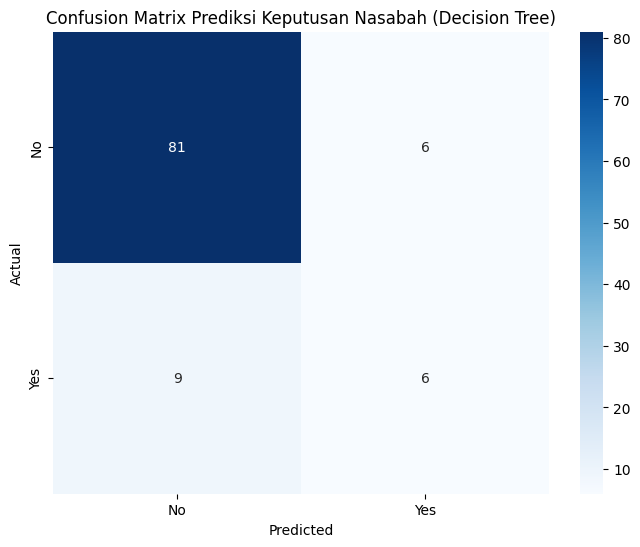

In [ ]:
#Visualisasi confusion matrix
cm = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix Prediksi Keputusan Nasabah (Decision Tree)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

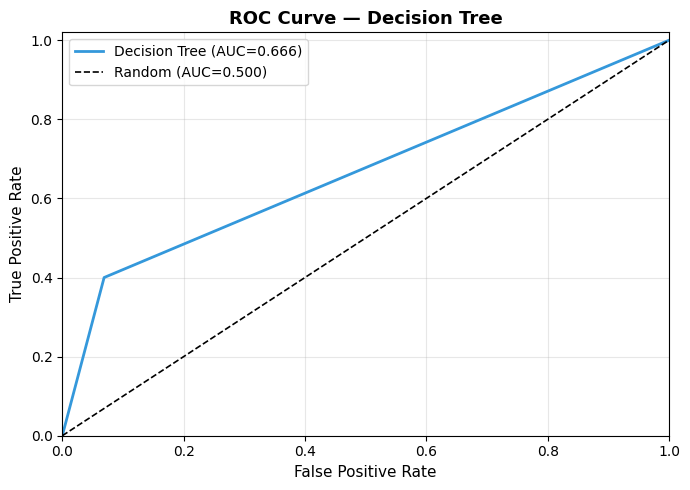

In [ ]:
# ROC Curve — Decision Tree
tree_proba = tree_best.predict_proba(X_test_scaled)[:, 1]
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_proba)
roc_auc = roc_auc_score(y_test, tree_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr_tree, tpr_tree, lw=2, color='#3498db', label=f'Decision Tree (AUC={roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1.2, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve — Decision Tree', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

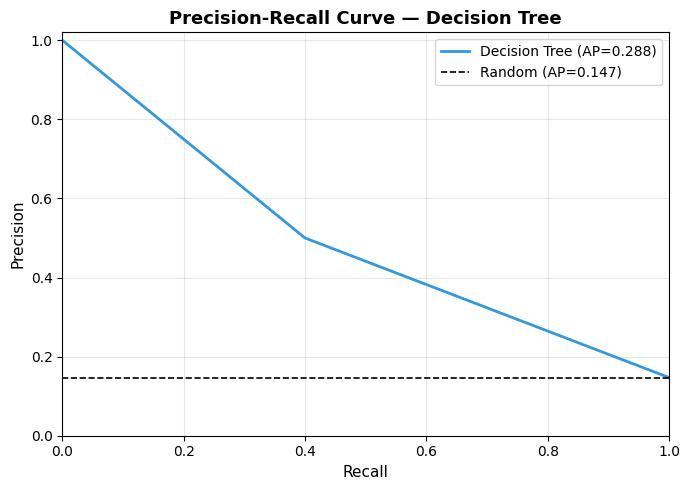

In [ ]:
# Precision-Recall Curve — Decision Tree
prec_tree, rec_tree, _ = precision_recall_curve(y_test, tree_proba)
ap_tree = average_precision_score(y_test, tree_proba)
baseline = (y_test == 1).mean()

plt.figure(figsize=(7, 5))
plt.plot(rec_tree, prec_tree, lw=2, color='#3498db', label=f'Decision Tree (AP={ap_tree:.3f})')
plt.axhline(baseline, color='k', linestyle='--', lw=1.2, label=f'Random (AP={baseline:.3f})')
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curve — Decision Tree', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

2. Random Forest

In [ ]:
#Pengukuran metrik evaluasi
print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        87
           1       1.00      0.27      0.42        15

    accuracy                           0.89       102
   macro avg       0.94      0.63      0.68       102
weighted avg       0.90      0.89      0.86       102



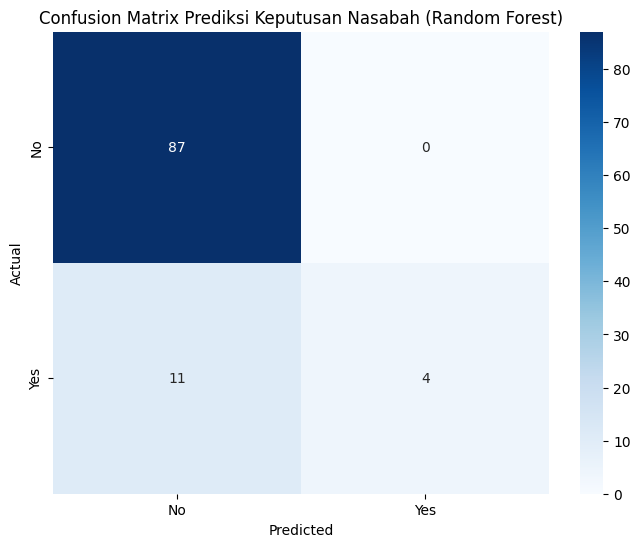

In [ ]:
#Visualisasi confusion matrix
cm = confusion_matrix(y_test, y_pred_forest)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix Prediksi Keputusan Nasabah (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

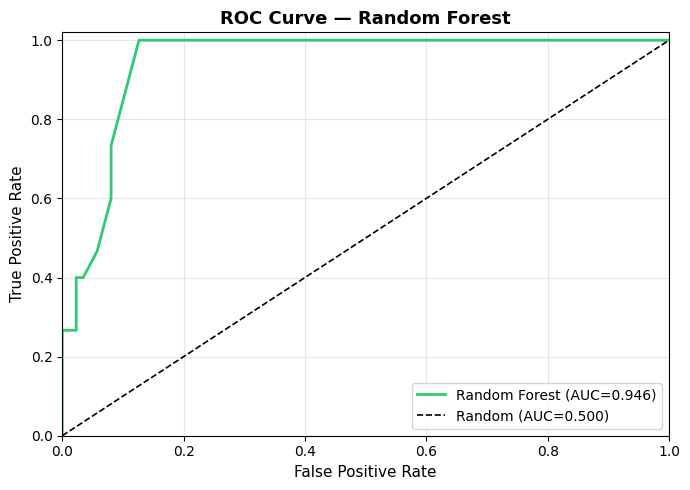

In [ ]:
# ROC Curve — Random Forest
forest_proba = forest_best.predict_proba(X_test_scaled)[:, 1]
fpr_forest, tpr_forest, _ = roc_curve(y_test, forest_proba)
roc_auc = roc_auc_score(y_test, forest_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr_forest, tpr_forest, lw=2, color='#2ecc71', label=f'Random Forest (AUC={roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1.2, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve — Random Forest', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

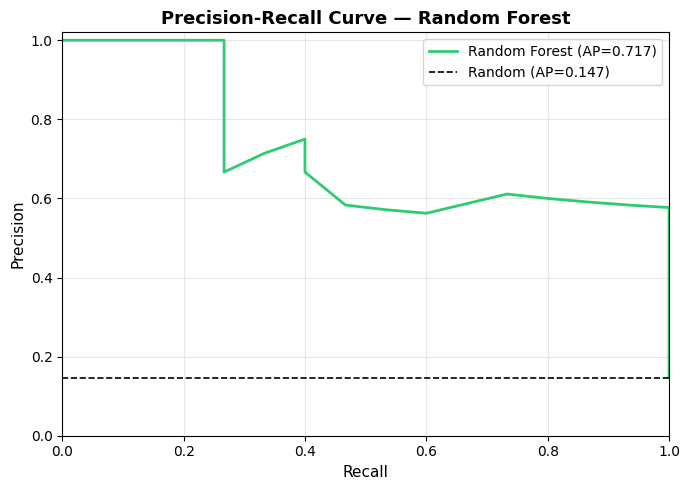

In [ ]:
# Precision-Recall Curve — Random Forest
prec_forest, rec_forest, _ = precision_recall_curve(y_test, forest_proba)
ap_forest = average_precision_score(y_test, forest_proba)
baseline = (y_test == 1).mean()

plt.figure(figsize=(7, 5))
plt.plot(rec_forest, prec_forest, lw=2, color='#2ecc71', label=f'Random Forest (AP={ap_forest:.3f})')
plt.axhline(baseline, color='k', linestyle='--', lw=1.2, label=f'Random (AP={baseline:.3f})')
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curve — Random Forest', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

3. XGBoost

In [ ]:
#Pengukuran metrik evaluasi
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96        87
           1       0.83      0.67      0.74        15

    accuracy                           0.93       102
   macro avg       0.89      0.82      0.85       102
weighted avg       0.93      0.93      0.93       102



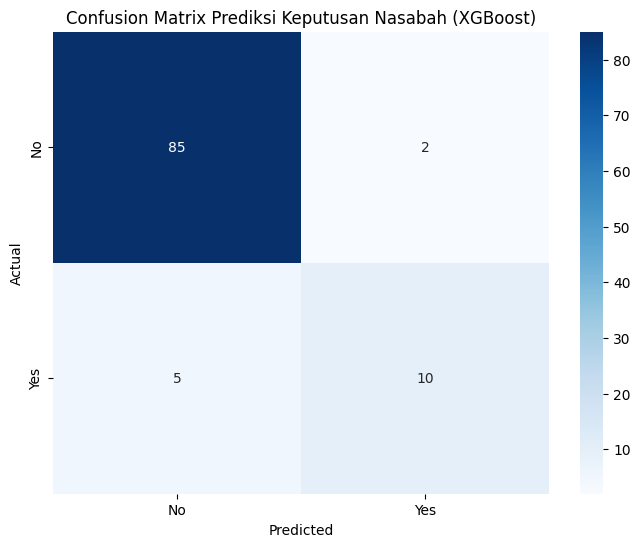

In [ ]:
#Visualisasi confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix Prediksi Keputusan Nasabah (XGBoost)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

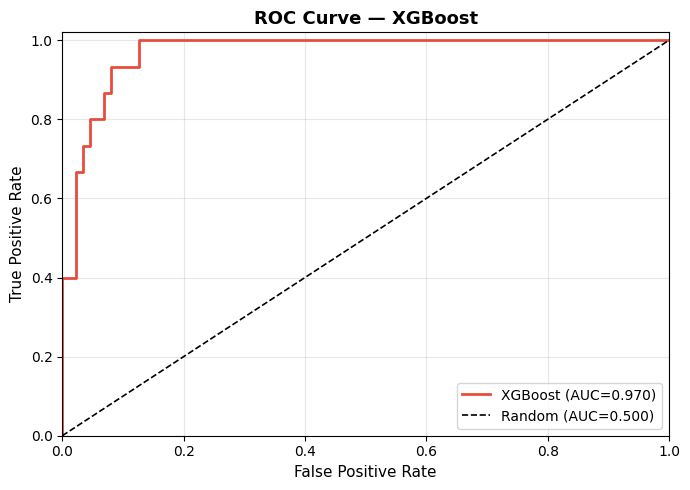

In [ ]:
# ROC Curve — XGBoost
xgb_proba = xgb_best.predict_proba(X_test_scaled)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
roc_auc = roc_auc_score(y_test, xgb_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr_xgb, tpr_xgb, lw=2, color='#e74c3c', label=f'XGBoost (AUC={roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1.2, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve — XGBoost', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

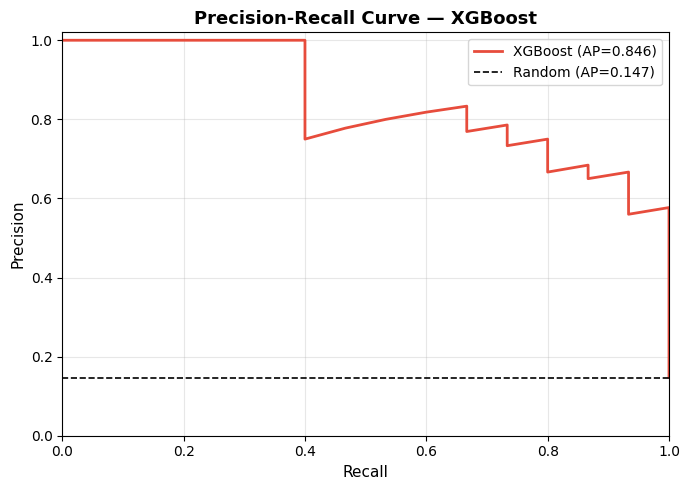

In [ ]:
# Precision-Recall Curve — XGBoost
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_proba)
ap_xgb = average_precision_score(y_test, xgb_proba)
baseline = (y_test == 1).mean()

plt.figure(figsize=(7, 5))
plt.plot(rec_xgb, prec_xgb, lw=2, color='#e74c3c', label=f'XGBoost (AP={ap_xgb:.3f})')
plt.axhline(baseline, color='k', linestyle='--', lw=1.2, label=f'Random (AP={baseline:.3f})')
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curve — XGBoost', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
**Perbandingan Singkat**

|Model|Akurasi|ROC-AUC|PR-AUC|
|:--|:---:|:--|:--|
|Decision Tree|85%|0,666|0,288|
|Random Forest|89%|0,946|0,717|
|XGBoost      |93%|0,97|0,846|

Model `XGBoost` memiliki performa paling optimal dalam melakukan klasifikasi.

---

##**Interpretasi Model**

In [ ]:
#Fitur paling berpengaruh (Decision Tree)
feature_importances = tree_best.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)
feature_importance_df[:5]

,Feature,Importance
6,duration,0.354765
2,balance,0.132212
5,month,0.118333
0,age,0.072365
26,poutcome_success,0.054246


In [ ]:
#Fitur paling berpengaruh (Random Forest)
feature_importances = forest_best.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)
feature_importance_df[:5]

,Feature,Importance
6,duration,0.365490
2,balance,0.108103
0,age,0.094257
5,month,0.079628
7,campaign,0.043760


In [ ]:
#Fitur paling berpengaruh (XGBoost)
feature_importances = xgb_best.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)
feature_importance_df[:5]

,Feature,Importance
26,poutcome_success,0.161356
24,contact_unknown,0.135854
17,job_student,0.061147
6,duration,0.054440
12,job_housemaid,0.042741


In [ ]:
#Fitur paling berpengaruh secara rata-rata ketiga model
fimp_data = {
    'Decision Tree': tree_best.feature_importances_,
    'Random Forest': forest_best.feature_importances_,
    'XGBoost'      : xgb_best.feature_importances_
}

# Normalisasi nilai importance setiap model (skala 0-1)
fimp_normalized = {name: imp / imp.sum() for name, imp in fimp_data.items()}
avg_importance = np.mean(list(fimp_normalized.values()), axis=0)

fimp_avg_df = pd.DataFrame({
    'Feature'          : X_train.columns,
    'Tree Importance'    : fimp_normalized['Decision Tree'],
    'Forest Importance'    : fimp_normalized['Random Forest'],
    'XGB Importance'   : fimp_normalized['XGBoost'],
    'Avg Importance'   : avg_importance
}).sort_values('Avg Importance', ascending=False).reset_index(drop=True)

#Agar memulai nomornya dari 1, bukan 0
fimp_avg_df.index += 1

print("-"* 60)
print("Top 10 Fitur yang Paling Berpengaruh (rata-rata 3 model):")
print("-" * 60)
print(f"{'':>4}  Fitur{'':<25} Importance")
for idx, row in fimp_avg_df.head(10).iterrows():
    print(f"  {idx:>2}. {row['Feature']:<30} {row['Avg Importance']:.4f}")

------------------------------------------------------------
Top 10 Fitur yang Paling Berpengaruh (rata-rata 3 model):
------------------------------------------------------------
      Fitur                          Importance
   1. duration                       0.2582
   2. balance                        0.0871
   3. poutcome_success               0.0806
   4. month                          0.0779
   5. contact_unknown                0.0725
   6. age                            0.0614
   7. pdays                          0.0344
   8. campaign                       0.0325
   9. job_student                    0.0242
  10. education                      0.0215


---
**INTERPRETASI MODEL**

---
1. **Best Model**

    Model terbaik berdasarkan pengukuran metrik evaluasi adalah **XGBoost** dengan `akurasi` prediksi mencapai **93 persen**. Selain itu, metrik `precision`, `recall`, dan `f1-score` nya adalah yang paling tinggi dan seimbang dibandingkan dua model lainnya. Hasil `ROC-AUC` dan `PR-AUC` nya juga sangat baik dengan nilai mendekati satu, yaitu **0,97** dan **0,846**. Artinya, model ini mampu mengklasifikasikan dua kelas tersebut dengan baik (tidak asal menebak).
2. **Feature Importance**

    Fitur yang paling mempengaruhi adalah **duration**, **balance**, dan **poutcome_success**.
    
    Fitur **duration** menunjukkan, bahwa semakin lama panggilan berlangsung, nasabah akan cenderung berlangganan. Namun, fitur durasi merupakan hasil pengukuran setelah terjadi Hal ini sesuai dengan pernyataan penelitian Moro, S. et al. (2014). Jika model ingin digunakan untuk memprediksi nasabah potensial sebelum melaksanakan kampanye, ia tidak bisa digunakan secara optimal. Salah satu solusi yang bisa dilakukan adalah melatih model tanpa data durasi. Meskipun akan mempengaruhi hasil evaluasi model, namun model dapat mempelajari pola data tanpa fitur durasi, sehingga dapat digunakan sebelum melakukan kampanye.

    Fitur **balance** menunjukkan, bahwa nasabah yang memiliki saldo tinggi cenderung menerima tawaran untuk berlangganan deposito berjangka.

    Fitur **poutcome_success** menunjukkan hasil kampanye promosi periode sebelumnya dapat menjadi faktor penentu untuk hasil kampanye saat ini, dimana pelanggan yang sebelumnya menerima tawaran, berpeluang lebih tinggi untuk menerima tawaran kembali.

##**Perhitungan Signature dan Penyimpanan File Prediksi**

In [ ]:
#Perhitungan signature untuk model terbaik (XGBoost)
prob_yes= xgb_proba
n_yes = (y_pred_xgb == 1).sum()
sig = int((prob_yes.sum() * 1_000_000)) % 1_000_000_000
signature = (n_yes * 1_000_000_000) + sig
print("="*40)
print("Model yang dipilih -> XGBoost")
print("="*40)
print("n_yes =", n_yes)
print("signature =", signature)

Model yang dipilih -> XGBoost
n_yes = 12
signature = 12011947356


In [ ]:
#Ringkasan Output yang Wajib
print("="*45)
print("FINAL PRINT — WAJIB SESUAI INSTRUKSI SOAL")
print("="*45)
print(f"seed                = {seed}")
print(f"personal_test_rows  = {len(personal_test)}")
print()
print("Metrik Decision Tree:")
print(classification_report(y_test, y_pred_tree))
print("Metrik Random Forest:")
print(classification_report(y_test, y_pred_forest))
print("Metrik XGBoost:")
print(classification_report(y_test, y_pred_xgb))
print(f"Model yang dipilih  = XGBoost")
print(f"n_yes               = {n_yes}")
print(f"signature           = {signature}")

FINAL PRINT — WAJIB SESUAI INSTRUKSI SOAL
seed                = 1135948523
personal_test_rows  = 102

Metrik Decision Tree:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        87
           1       0.50      0.40      0.44        15

    accuracy                           0.85       102
   macro avg       0.70      0.67      0.68       102
weighted avg       0.84      0.85      0.85       102

Metrik Random Forest:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        87
           1       1.00      0.27      0.42        15

    accuracy                           0.89       102
   macro avg       0.94      0.63      0.68       102
weighted avg       0.90      0.89      0.86       102

Metrik XGBoost:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        87
           1       0.83      0.67      0.74        15

    accuracy        

In [ ]:
#Save hasil prediksi
pred_df = personal_test.copy()
pred_df['y_pred']    = y_pred_xgb
pred_df['prob_yes']  = xgb_proba

output_filename = f'pred_{NIM}.csv'
pred_df.to_csv(output_filename, index=False)
print(f"File prediksi disimpan: {output_filename}")
print(f"Jumlah baris         : {len(pred_df)}")
pred_df[['y', 'y_pred', 'prob_yes']].head(10)

File prediksi disimpan: pred_36250030.csv
Jumlah baris         : 102


,y,y_pred,prob_yes
1248,no,0,6.470778e-03
2853,no,0,3.947975e-03
2153,no,0,6.335029e-06
1451,no,0,6.486072e-02
2255,no,0,2.193446e-04
223,no,0,6.803647e-04
2164,no,0,1.330590e-07
4300,yes,0,3.753998e-01
3847,no,0,2.179998e-05
3323,no,0,7.909866e-05


##**Limitasi**

---
1. **Data Imbalanced:** Dataset sangat tidak seimbang (88,5% 'no' dan 11,5% 'yes'). Meskipun ditangani dengan `class_weight`, hasilnya tetap memengaruhi performa model terhadap kelas minoritas.

2. **Fitur `duration`:** Durasi panggilan hanya diketahui setelah panggilan selesai, sehingga tidak dapat digunakan untuk prediksi sebelum melaksanakan kampanye atau menghubungi nasabah. Untuk mengatasinya, fitur ini perlu dihapus.

3. **Fenomena *Concept Drift*:** Model dilatih menggunakan data historis yang statis/tetap. Sedangkan, hubungan perilaku/karakteristik nasabah terhadap keputusan langganan dapat berubah-ubah seiring berjalannya waktu. Sehingga, model perlu dilatih dan disesuaikan secara berkala.

4. **Nilai `unknown` pada Beberapa Kolom:** Beberapa fitur seperti `education`, `contact`, dan `poutcome` memiliki nilai `unknown` yang tidak dapat diisi/diimputasi secara akurat. Sehingga, model dapat kehilangan informasi penting untuk melakukan prediksi.

---

##**Kesimpulan & Rekomendasi**

---
**Kesimpulan**

Kampanye promosi membutuhkan sumber daya yang cukup banyak, namun hasilnya tidak signifikan. Untuk mengatasi masalah ini, telah dibuat tiga model klasifikasi yang akan membantu memprediksi nasabah seperti apa yang akan menerima tawaran langganan. Berdasarkan ketiga model tersebut, model yang paling optimal adalah **XGBoost**. Nilai PR-AUC yang tinggi menunjukkan model ini mampu mengklasifikasikan data dengan baik, meskipun data tidak seimbang.

Fitur yang paling berpengaruh terhadap keputusan nasabah untuk berlangganan adalah `duration`, `balance`, dan `poutcome_success`.
- Semakin lama panggilan berlangsung, semakin besar kemungkinan nasabah berlangganan.
- Nasabah dengan saldo yang tinggi lebih berpeluang/tertarik untuk berlangganan.
- Hasil kampanye sebelumnya dapat menjadi faktor penentu keputusan kampanye saat ini.

---

**Rekomendasi**
1. **Prioritaskan nasabah dengan riwayat kampanye berhasil** (`poutcome = success`) mereka memiliki tingkat konversi tinggi.
2. **Tingkatkan durasi panggilan** karena durasi berkorelasi kuat dengan konversi.
3. **Targetkan nasabah bersaldo tinggi** untuk penawaran.
4. **Utamakan bulan Maret, September-Oktober, dan Desember** sebagai bulan promosi karena memiliki tingkat konversi yang paling tinggi di sepanjang tahun.
5. **Gunakan model ini untuk scoring nasabah** sebelum kampanye, sehingga sumber daya difokuskan pada nasabah dengan probabilitas konversi tertinggi (berlangganan).
6. **Perkembangan model:** Membuat model baru menggunakan data tanpa fitur `duration` agar hasilnya lebih mewakili/realistis. Selain itu, lakukan pengawasan dan latih model secara berkala agar selalu relevan dengan perkembangan/perubahan fitur nasabah.
---

#**Sumber Referensi**
---
**Referensi Proyek**

---
- **Kaggle Notebook**: Syarief, F. *Banking Dataset - Marketing Targets*. Diakses pada 15 Juni 2026 melalui https://www.kaggle.com/code/fathurrs/banking-dataset-marketing-targets

- **Kaggle Notebook**: Helmi, F. *Potential Customer Prediction to Open Term Deposit*. Diakses pada 15 Juni 2026 melalui https://www.kaggle.com/code/ffarishelmi/potential-customer-prediction-to-open-term-deposit

---
**Daftar Pustaka**

---
- Chian, L. X., Khaw, K. W., Chew, X., Alnoor, A., & Ng, W. C. (2024). Bank Direct Marketing Campaign Success Prediction. Applied Mathematics and Computational Intelligence (AMCI), 13(3), 95–114. https://doi.org/10.58915/amci.v13i3.644

- Chihaoui, N., Waleed, A., Mufleh, A. S. S., Alshraah, S. M., Alajmi, L. H. R., & Altuwayjiri, S. (2026). A comprehensive review on AI-based crop disease detection using leaf image classification and explainable AI. Discover Applied Sciences, 8(6), 1–27. https://doi.org/10.1007/s42452-026-08684-0

#**Lampiran**

In [ ]:
#Menghapus day dari num_cols karena tidak perlu divisualisasikan
num_cols.remove('day')

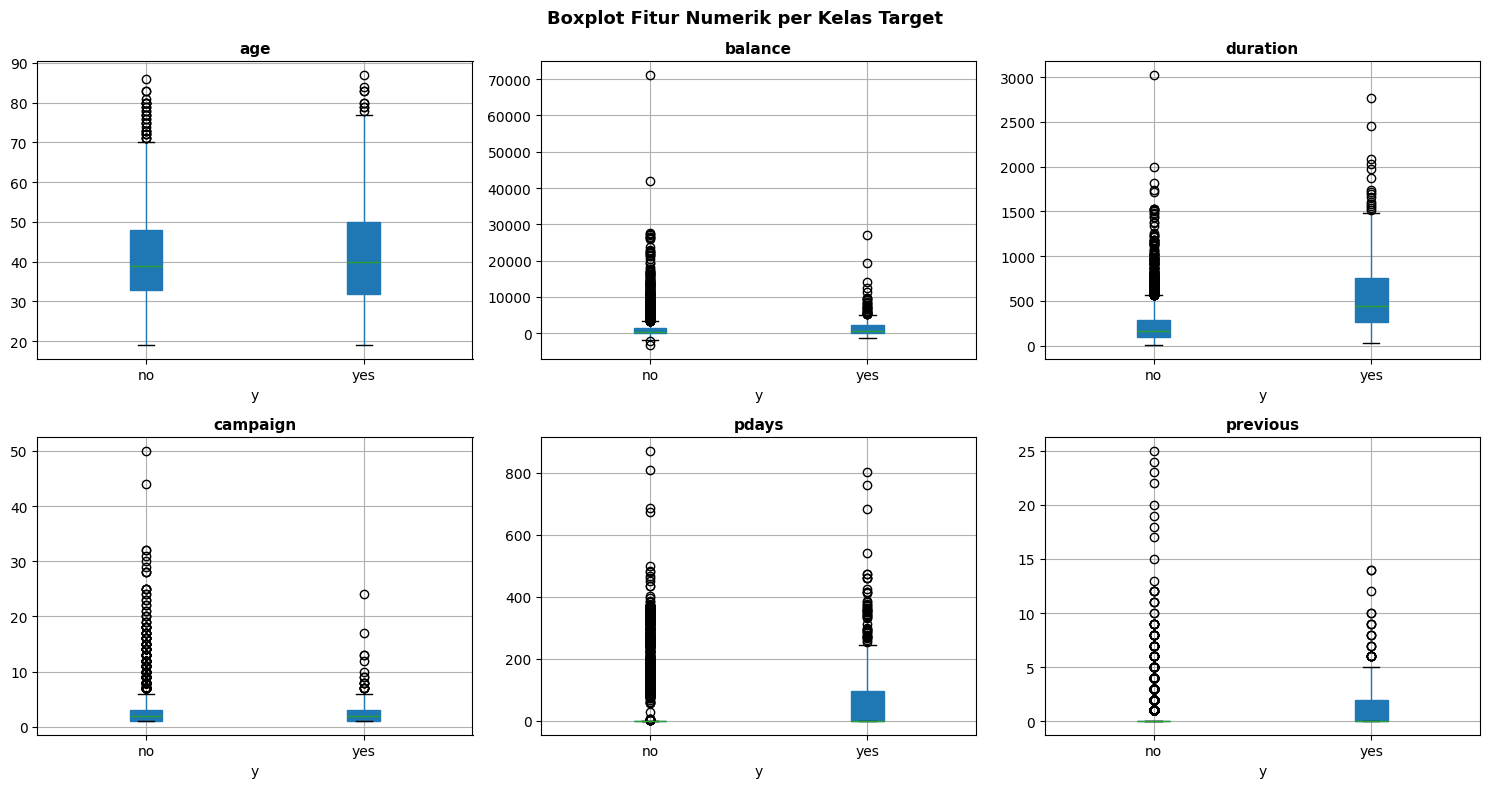

In [ ]:
# Boxplot Fitur Numerik berdasarkan Variabel Target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='y', ax=axes[i], patch_artist=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('y')

plt.suptitle('Boxplot Fitur Numerik per Kelas Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
*Data numerik mengandung banyak nilai ekstreme (**outlier**), namun hal ini telah diatasi oleh **robustscaler***.

---

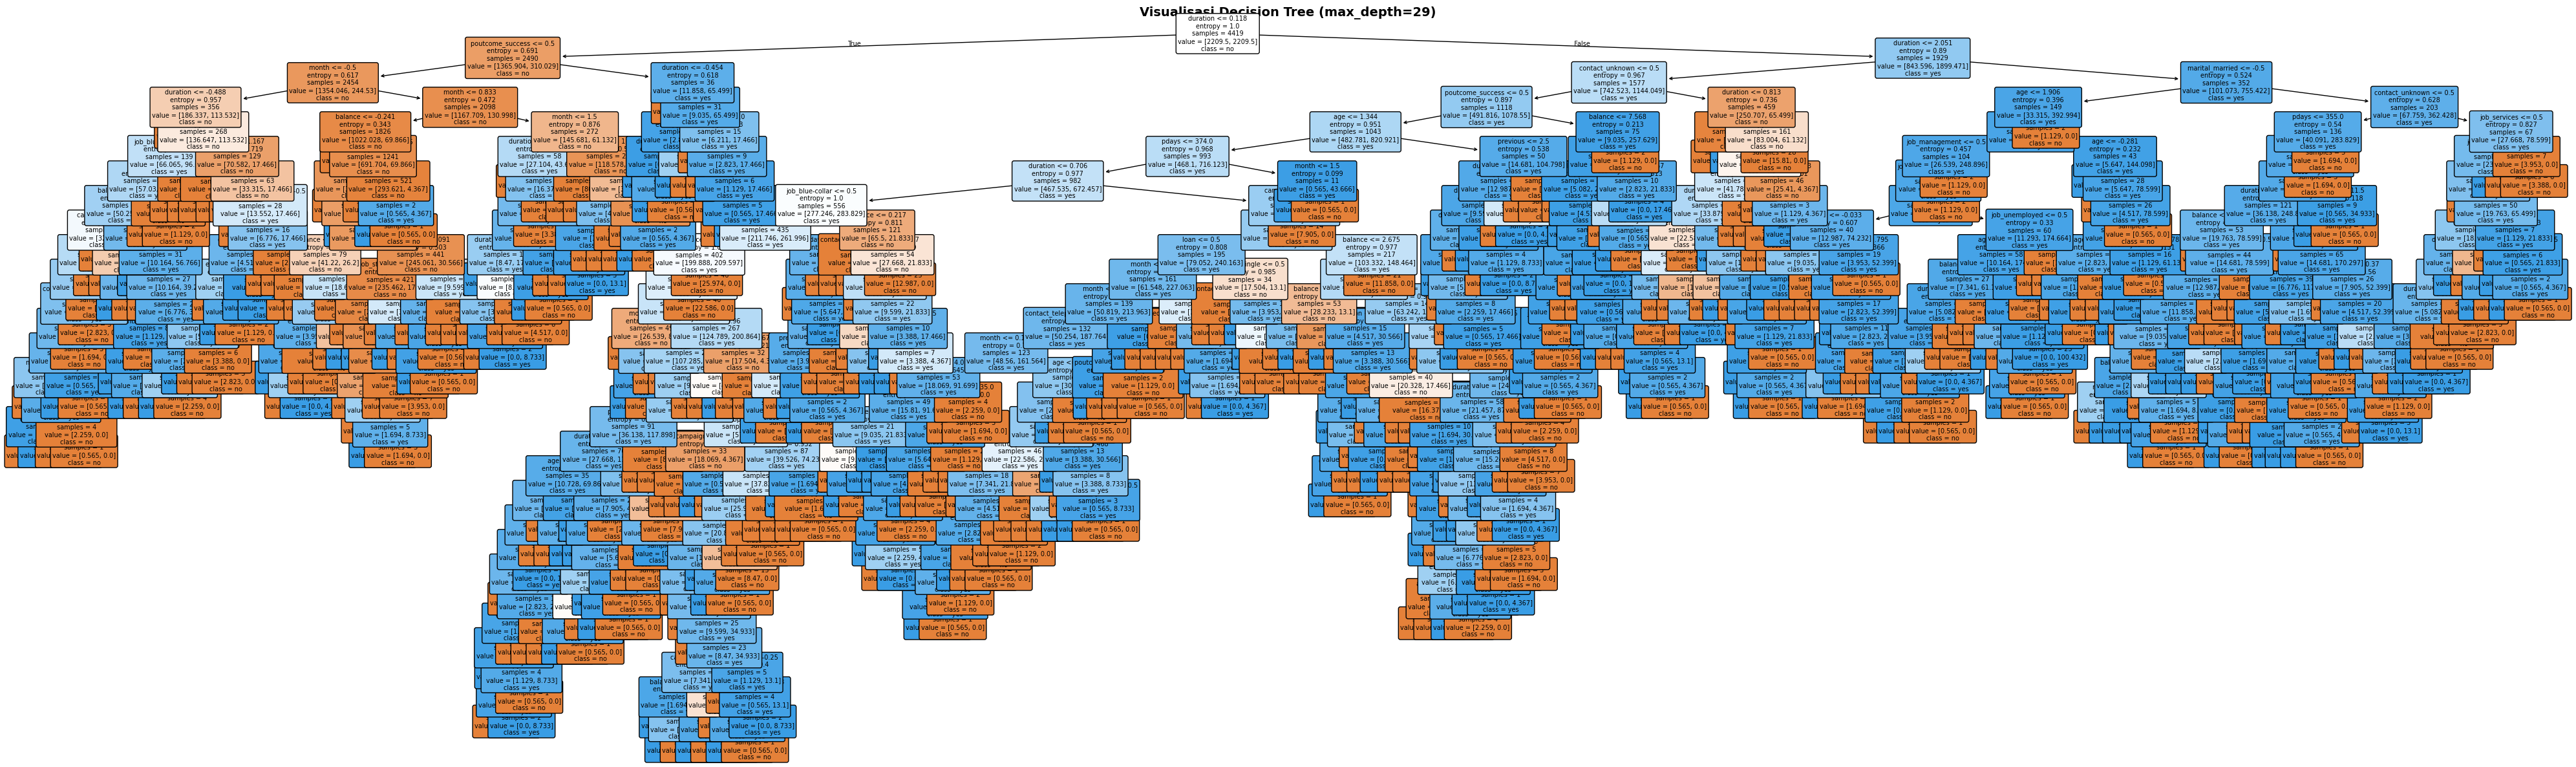

Kedalaman pohon  : 29
Jumlah leaf      : 473


In [ ]:
# Visualisasi Decision Tree
plt.figure(figsize=(40, 12))
plot_tree(
    tree_best,
    feature_names = X_train.columns,
    class_names   = ['no', 'yes'],
    filled        = True,
    rounded       = True,
    fontsize      = 7
)
plt.title(
    f'Visualisasi Decision Tree (max_depth={tree_best.get_depth()})',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()
print(f"Kedalaman pohon  : {tree_best.get_depth()}")
print(f"Jumlah leaf      : {tree_best.get_n_leaves()}")